# Library and important variable initialization

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
plt.rcParams['figure.figsize'] = (10,5)
sns.set(style="whitegrid")

RANDOM_STATE = 42

print("Environment ready.")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn:", sns.__version__)
print("matplotlib:", plt.matplotlib.__version__)


Environment ready.
pandas: 2.2.2
numpy: 2.0.2
seaborn: 0.13.2
matplotlib: 3.10.0


# Read and display Dataset sample

In [2]:
# Read daily and hourly dataset
daily_df = pd.read_csv("day.csv")
hourly_df = pd.read_csv("hour.csv")

# Display the first 8 rows of the daily dataset
print("Daily shape:", daily_df.shape)
display(daily_df.head(8))

print("\n")

# Display the first 8 rows of the hourly dataset
print("Hourly shape:", hourly_df.shape)
display(hourly_df.head(8))



Daily shape: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959




Hourly shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3


# Dataset information

## Daily dataset information

In [3]:
# Display the dataset information and descriptive statistics for the daily dataset
print("=== DAILY dataset INFO ===")
display(daily_df.info())

print("\n=== DAILY dataset Descriptive value (numeric) ===")
display(daily_df.describe().T)

print("\n=== DAILY DESC (categorical) ===")
display(daily_df.describe(include='object').T)

=== DAILY dataset INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


None


=== DAILY dataset Descriptive value (numeric) ===


,count,mean,std,min,25%,50%,75%,max
instant,731.0,366.000000,211.165812,1.000000,183.500000,366.000000,548.500000,731.000000
season,731.0,2.496580,1.110807,1.000000,2.000000,3.000000,3.000000,4.000000
yr,731.0,0.500684,0.500342,0.000000,0.000000,1.000000,1.000000,1.000000
mnth,731.0,6.519836,3.451913,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,731.0,0.028728,0.167155,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,731.0,2.997264,2.004787,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,731.0,0.683995,0.465233,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,731.0,1.395349,0.544894,1.000000,1.000000,1.000000,2.000000,3.000000
temp,731.0,0.495385,0.183051,0.059130,0.337083,0.498333,0.655417,0.861667
atemp,731.0,0.474354,0.162961,0.079070,0.337842,0.486733,0.608602,0.840896



=== DAILY DESC (categorical) ===


,count,unique,top,freq
dteday,731,731,2012-12-31,1


## Hourly dataset information

In [4]:
# Display the dataset information and descriptive statistics for the hourly dataset
print("=== HOURLY INFO ===")
display(hourly_df.info())

print("\n=== HOURLY DESC (numeric) ===")
display(hourly_df.describe().T)

print("\n=== HOURLY DESC (categorical) ===")
display(hourly_df.describe(include='object').T)

=== HOURLY INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


None


=== HOURLY DESC (numeric) ===


,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000



=== HOURLY DESC (categorical) ===


,count,unique,top,freq
dteday,17379,731,2012-12-31,24


## Determine missing value , parsing issue or duplicate in the daily dataset

In [5]:
# Check for missing values in daily dataset
print("Number of missing value in the daily dataset :")
display(daily_df.isnull().sum().sort_values(ascending=False))

Number of missing value in the daily dataset :


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
# Check for duplicate rows in daily dataset
print("\n Number of  duplicate rows in the daily dataset:", daily_df.duplicated().sum())


 Number of  duplicate rows in the daily dataset: 0


In [7]:
# Check for date parsing errors in daily dataset
daily_df['dteday'] = pd.to_datetime(daily_df['dteday'], errors='coerce')
print("Number of Error parsing dteday column:", daily_df['dteday'].isnull().sum())

Number of Error parsing dteday column: 0


## Determine missing value , parsing issue or duplicate in the hourly dataset

In [8]:
# Check for missing values in hourly dataset
print("Number of missing value in the hourly dataset :")
display(hourly_df.isnull().sum().sort_values(ascending=False))

Number of missing value in the hourly dataset :


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [9]:
# Check for duplicate rows in hourly dataset
print("\n Number of duplicate rows in the hourly dataset:", hourly_df.duplicated().sum())


 Number of duplicate rows in the hourly dataset: 0


In [10]:
# Check for date parsing errors in hourly dataset
hourly_df['dteday'] = pd.to_datetime(hourly_df['dteday'], errors='coerce')
print("Number of Error parsing dteday column:", hourly_df['dteday'].isnull().sum())

Number of Error parsing dteday column: 0


# Decoding Column of interest for better data visualization

## Mapping rule

In [11]:
# Mappings for categorical variables
season_mapping = {
    1: "spring",
    2: "summer",
    3: "fall",
    4: "winter"
}
year_mapping = {
    0: "2011",
    1: "2012"
}
weekday_mapping = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}
weather_condition_mapping = {
   1: "Clear",
   2: "Mist/Cloudy",
   3: "LightRain/Snow",
   4: "HeavyRain/Snow"
}

working_day = {
    0:'no',
    1:'yes'
}

month_mapping = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

## Create new column with the mapping

In [12]:
# Create a new column for the season name
daily_df["season_name"] = daily_df["season"].map(season_mapping)
hourly_df["season_name"] = hourly_df["season"].map(season_mapping)

# Create a new column for weather condition
daily_df['weather_condition_name'] = daily_df['weathersit'].map(weather_condition_mapping)
hourly_df['weather_condition_name'] = hourly_df['weathersit'].map(weather_condition_mapping)

# Create new column for working day
daily_df['is_working_day'] = daily_df['workingday'].map(working_day)
hourly_df['is_working_day'] = hourly_df['workingday'].map(working_day)

daily_df["day_name"] = daily_df["weekday"].map(weekday_mapping)
hourly_df["day_name"] = hourly_df["weekday"].map(weekday_mapping)

# Create a new column for holiday
daily_df['is_holiday'] = daily_df['holiday'].map(working_day)
hourly_df['is_holiday'] = hourly_df['holiday'].map(working_day)

# Create new  column for the month
daily_df['month_name'] = daily_df['mnth'].map(month_mapping)
hourly_df['month_name'] = hourly_df['mnth'].map(month_mapping)

#Create new column for year
daily_df['year_val'] = daily_df['yr'].map(year_mapping)
hourly_df['year_val'] = hourly_df['yr'].map(year_mapping)


print("\n === DAILY dataset INFO ===\n ")
print(display(daily_df.head(8)))
print("\n === HOURLY dataset INFO === \n")
print(display(hourly_df.head(8)))

# Rename cnt column
daily_df = daily_df.rename(columns={'cnt': 'total_bike_rental'})
hourly_df = hourly_df.rename(columns={'cnt': 'total_bike_rental'})



 === DAILY dataset INFO ===
 


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,casual,registered,cnt,season_name,weather_condition_name,is_working_day,day_name,is_holiday,month_name,year_val
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,...,331,654,985,spring,Mist/Cloudy,no,Saturday,no,January,2011
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,...,131,670,801,spring,Mist/Cloudy,no,Sunday,no,January,2011
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,...,120,1229,1349,spring,Clear,yes,Monday,no,January,2011
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,...,108,1454,1562,spring,Clear,yes,Tuesday,no,January,2011
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,...,82,1518,1600,spring,Clear,yes,Wednesday,no,January,2011
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,...,88,1518,1606,spring,Clear,yes,Thursday,no,January,2011
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,...,148,1362,1510,spring,Mist/Cloudy,yes,Friday,no,January,2011
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,...,68,891,959,spring,Mist/Cloudy,no,Saturday,no,January,2011


None

 === HOURLY dataset INFO === 



,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,casual,registered,cnt,season_name,weather_condition_name,is_working_day,day_name,is_holiday,month_name,year_val
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,3,13,16,spring,Clear,no,Saturday,no,January,2011
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,8,32,40,spring,Clear,no,Saturday,no,January,2011
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,5,27,32,spring,Clear,no,Saturday,no,January,2011
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,3,10,13,spring,Clear,no,Saturday,no,January,2011
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0,1,1,spring,Clear,no,Saturday,no,January,2011
5,6,2011-01-01,1,0,1,5,0,6,0,2,...,0,1,1,spring,Mist/Cloudy,no,Saturday,no,January,2011
6,7,2011-01-01,1,0,1,6,0,6,0,1,...,2,0,2,spring,Clear,no,Saturday,no,January,2011
7,8,2011-01-01,1,0,1,7,0,6,0,1,...,1,2,3,spring,Clear,no,Saturday,no,January,2011


None


# Data visualization

## Correlation matrix

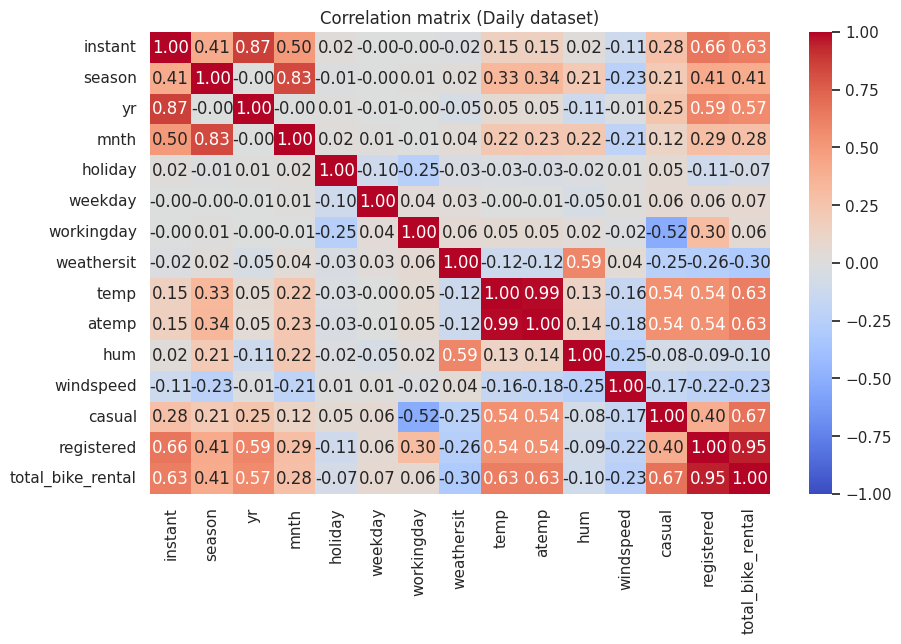

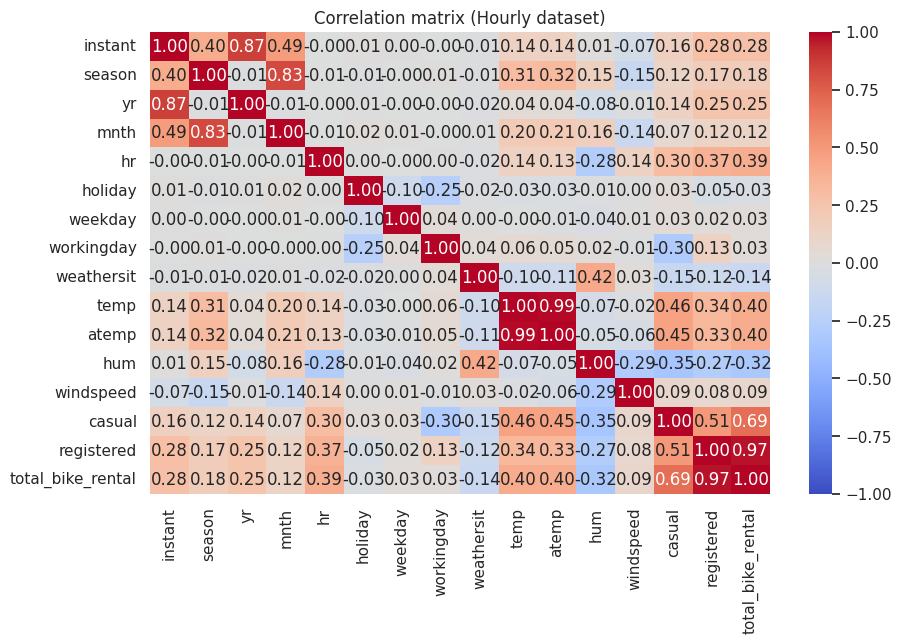

In [13]:
# Correlation matrix for daily dataset
daily_numerical_df = daily_df.select_dtypes(include=['number'])
plt.figure(figsize=(10,6))
sns.heatmap(daily_numerical_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation matrix (Daily dataset)")
plt.show()

# Correlation matrix for hourly dataset
hourly_numerical_df = hourly_df.select_dtypes(include=['number'])
plt.figure(figsize=(10,6))
sns.heatmap(hourly_numerical_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation matrix (Hourly dataset)")
plt.show()

## Total bike rental distribution

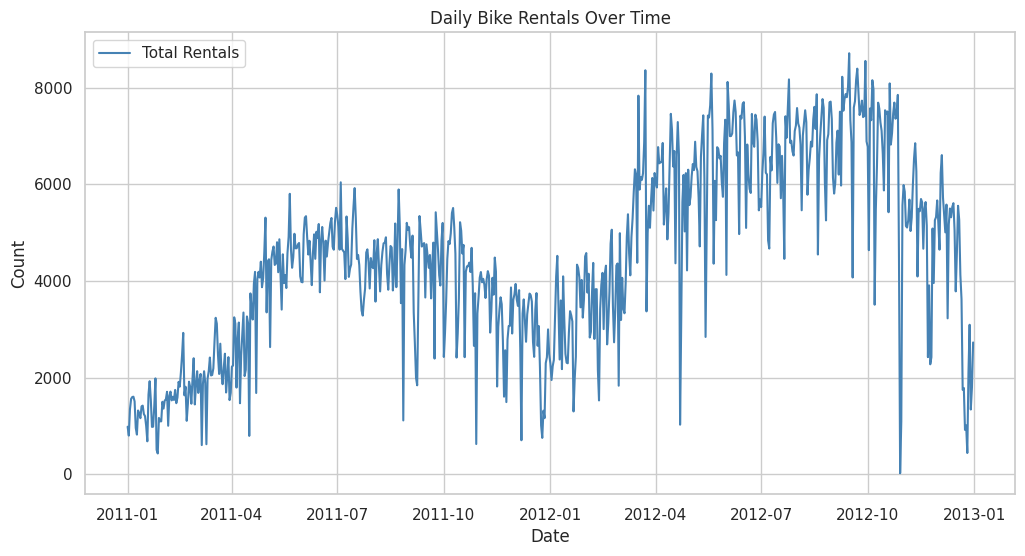

In [14]:
# Time series plot of total bike rentals over time (daily dataset)
plt.figure(figsize=(12,6))
plt.plot(daily_df['dteday'], daily_df['total_bike_rental'], label='Total Rentals', color='steelblue')
plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.show()


## Total bike rental per season

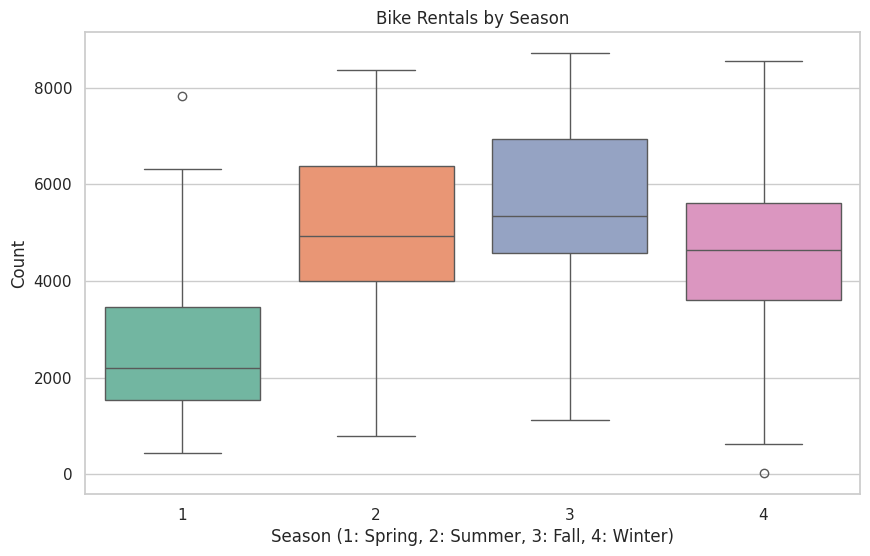

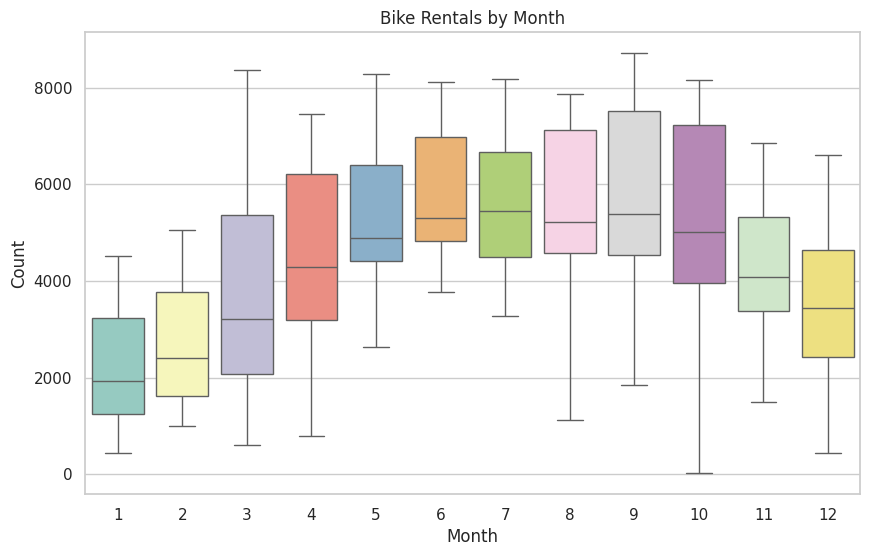

In [15]:
# Total bike rentals by season (daily dataset)
plt.figure(figsize=(10,6))
sns.boxplot(x='season', y='total_bike_rental', data=daily_df, hue='season', palette='Set2', legend=False)
plt.title("Bike Rentals by Season")
plt.xlabel("Season (1: Winter, 2: Spring, 3: Summer, 4: Winter)")
plt.ylabel("Count")
plt.show()

# Total bike rentals by month (daily dataset)
plt.figure(figsize=(10,6))
sns.boxplot(x='mnth', y='total_bike_rental', data=daily_df, hue='mnth', palette='Set3', legend=False)
plt.title("Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()


## Bike rentals by day of the week

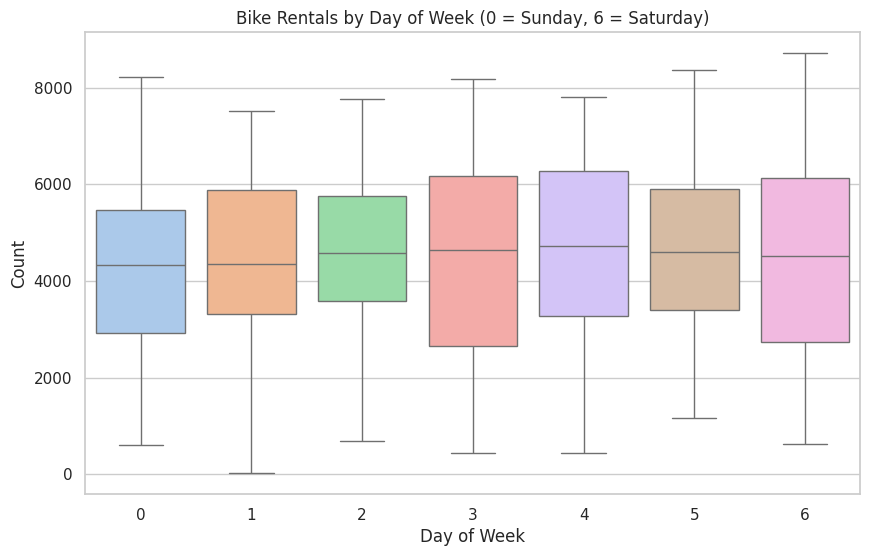

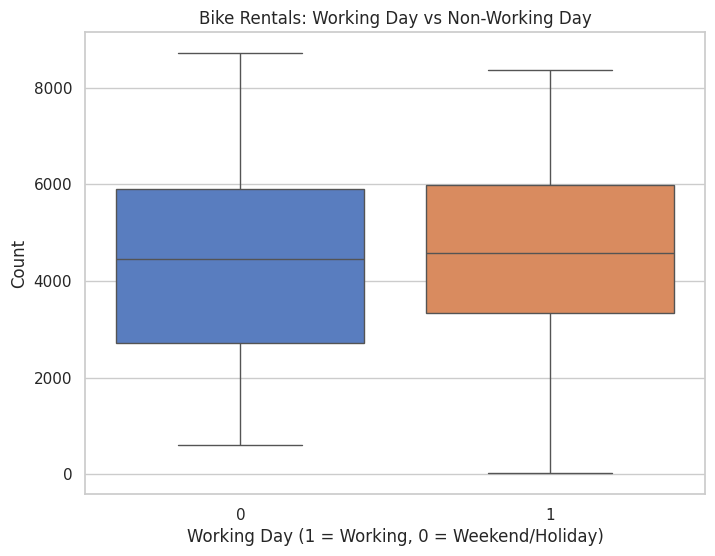

In [16]:
# Total bike rentals by day of the week (daily dataset)
plt.figure(figsize=(10,6))
sns.boxplot(x='weekday', y='total_bike_rental', data=daily_df, hue='weekday', palette='pastel', legend=False)
plt.title("Bike Rentals by Day of Week (0 = Sunday, 6 = Saturday)")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

# Total bike rentals: Working day vs Non-working day (daily dataset)
plt.figure(figsize=(8,6))
sns.boxplot(x='workingday', y='total_bike_rental', data=daily_df, hue='workingday', palette='muted', legend=False)
plt.title("Bike Rentals: Working Day vs Non-Working Day")
plt.xlabel("Working Day (1 = Working, 0 = Weekend/Holiday)")
plt.ylabel("Count")
plt.show()

## Environment variables impact on total bike rental

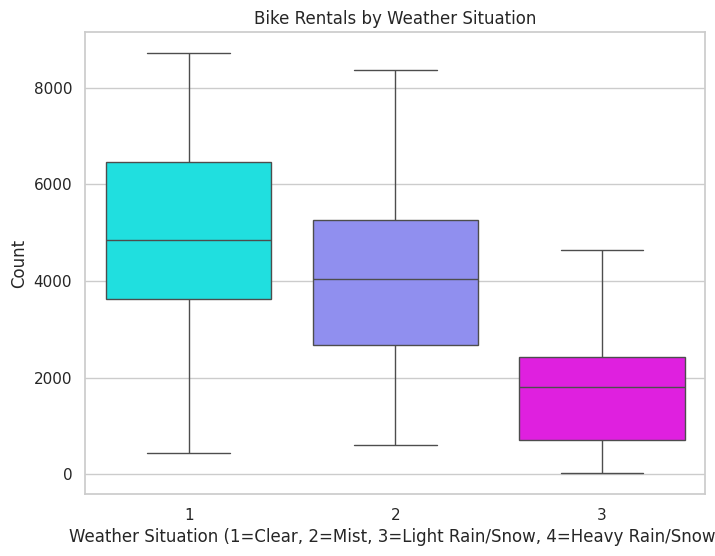

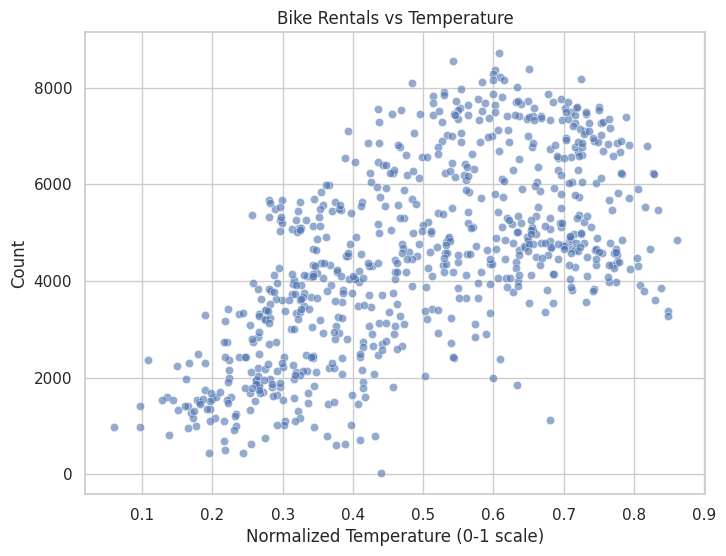

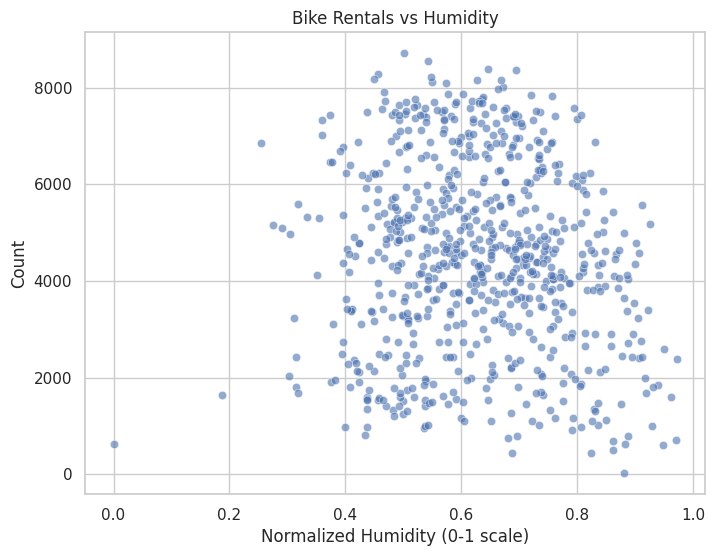

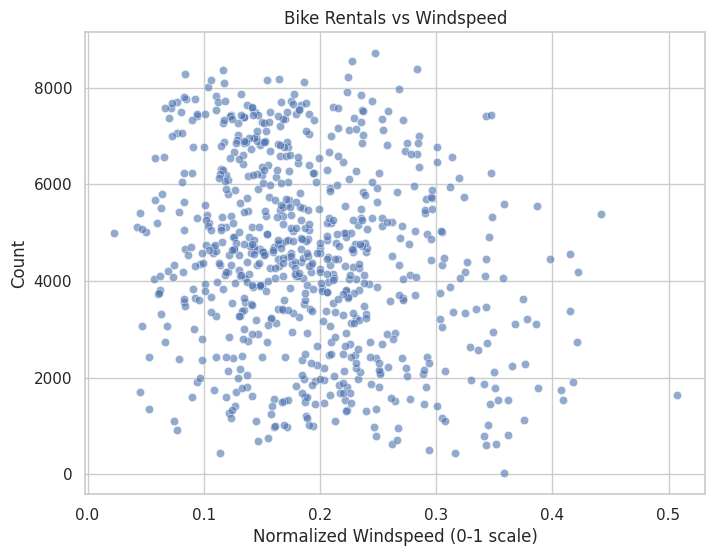

In [17]:
# Total bike rentals by weather situation (daily dataset)
plt.figure(figsize=(8,6))
sns.boxplot(x='weathersit', y='total_bike_rental', data=daily_df, hue='weathersit', palette='cool', legend=False)
plt.title("Bike Rentals by Weather Situation")
plt.xlabel("Weather Situation (1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain/Snow)")
plt.ylabel("Count")
plt.show()

# Scatter plots for continuous variables vs total bike rentals (daily dataset)
plt.figure(figsize=(8,6))
sns.scatterplot(x='temp', y='total_bike_rental', data=daily_df, alpha=0.6)
plt.title("Bike Rentals vs Temperature")
plt.xlabel("Normalized Temperature (0-1 scale)")
plt.ylabel("Count")
plt.show()

# Scatter plot for humidity vs total bike rentals
plt.figure(figsize=(8,6))
sns.scatterplot(x='hum', y='total_bike_rental', data=daily_df, alpha=0.6)
plt.title("Bike Rentals vs Humidity")
plt.xlabel("Normalized Humidity (0-1 scale)")
plt.ylabel("Count")
plt.show()

# Scatter plot for windspeed vs total bike rentals
plt.figure(figsize=(8,6))
sns.scatterplot(x='windspeed', y='total_bike_rental', data=daily_df, alpha=0.6)
plt.title("Bike Rentals vs Windspeed")
plt.xlabel("Normalized Windspeed (0-1 scale)")
plt.ylabel("Count")
plt.show()

## Hourly Data visualization

### Hourly rentals per hour of the day

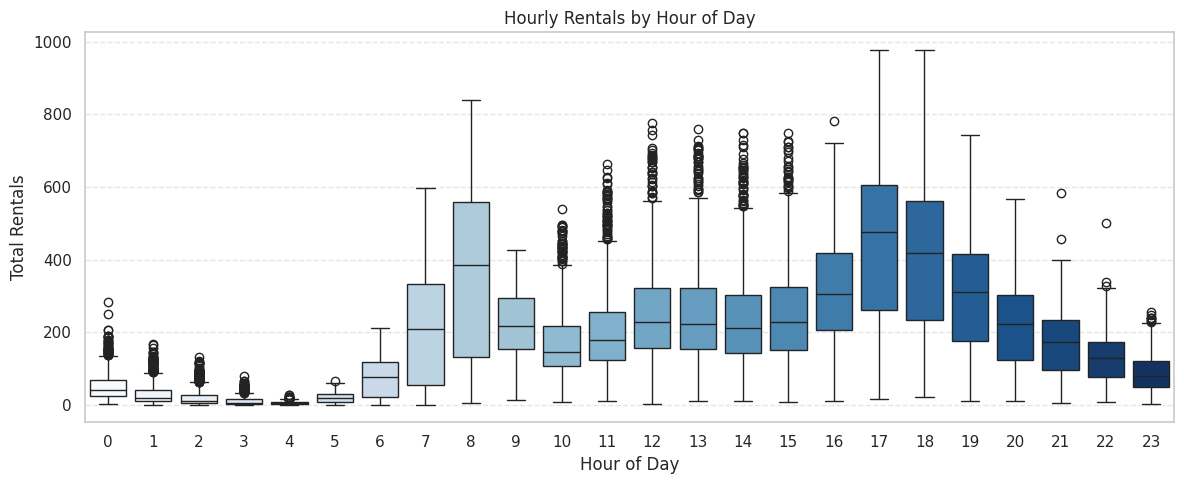

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total bike rentals by hour of the day (hourly dataset)
plt.figure(figsize=(12,5))
sns.boxplot(
    x='hr', y='total_bike_rental', data=hourly_df,
    hue='hr', palette='Blues', legend=False
)
plt.title('Hourly Rentals by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Rentals')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

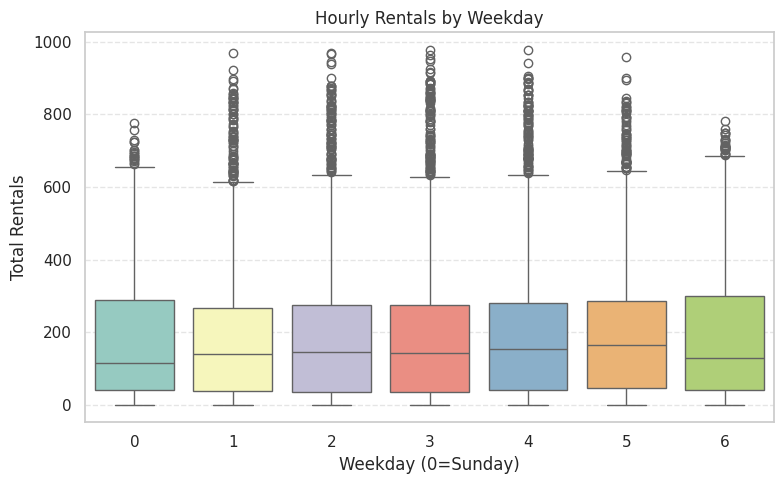

In [19]:
# Total bike rentals by day of the week (hourly dataset)
plt.figure(figsize=(8,5))
sns.boxplot(x='weekday', y='total_bike_rental', data=hourly_df, hue='weekday', palette='Set3', legend=False)
plt.title('Hourly Rentals by Weekday')
plt.xlabel('Weekday (0=Sunday)')
plt.ylabel('Total Rentals')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3237936685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='workingday', y='total_bike_rental', data=hourly_df, palette='Set2')


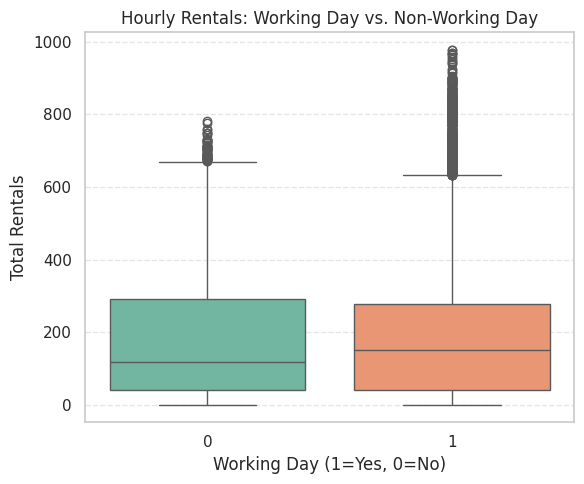

In [20]:
# Total bike rentals: Working day vs Non-working day (hourly dataset)
plt.figure(figsize=(6,5))
sns.boxplot(x='workingday', y='total_bike_rental', data=hourly_df, palette='Set2')
plt.title('Hourly Rentals: Working Day vs. Non-Working Day')
plt.xlabel('Working Day (1=Yes, 0=No)')
plt.ylabel('Total Rentals')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Hourly rentals variation in function of the temperature

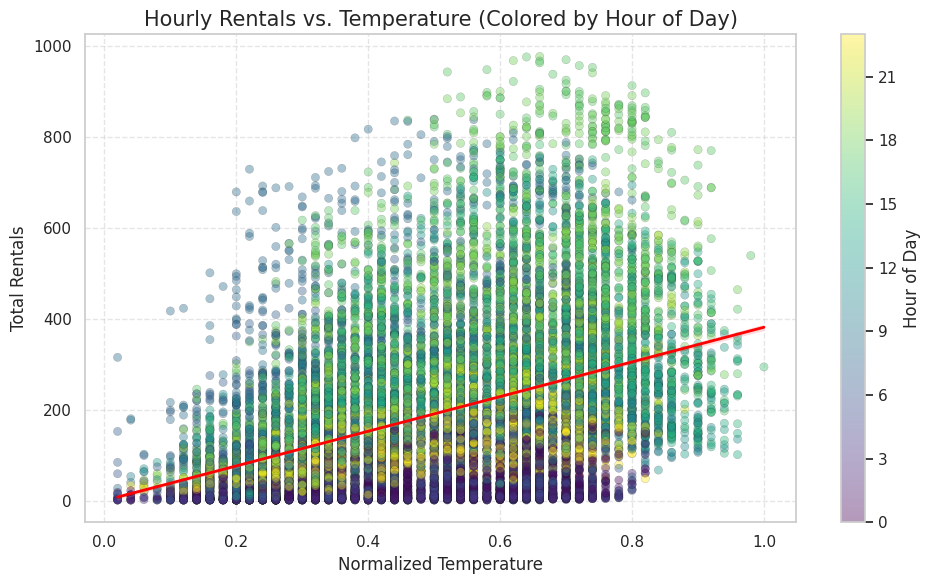

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot for temperature vs total bike rentals, colored by hour of day
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    hourly_df['temp'], hourly_df['total_bike_rental'],
    c=hourly_df['hr'], cmap='viridis',
    alpha=0.4, edgecolors='k', linewidths=0.2
)

# Add a regression line (trend)
sns.regplot(
    x='temp', y='total_bike_rental', data=hourly_df,
    scatter=False, color='red', line_kws={'linewidth':2}
)

plt.title('Hourly Rentals vs. Temperature (Colored by Hour of Day)', fontsize=15)
plt.xlabel('Normalized Temperature', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add colorbar for hour of day
cbar = plt.colorbar(scatter, ticks=range(0, 24, 3))
cbar.set_label('Hour of Day')

plt.tight_layout()
plt.show()


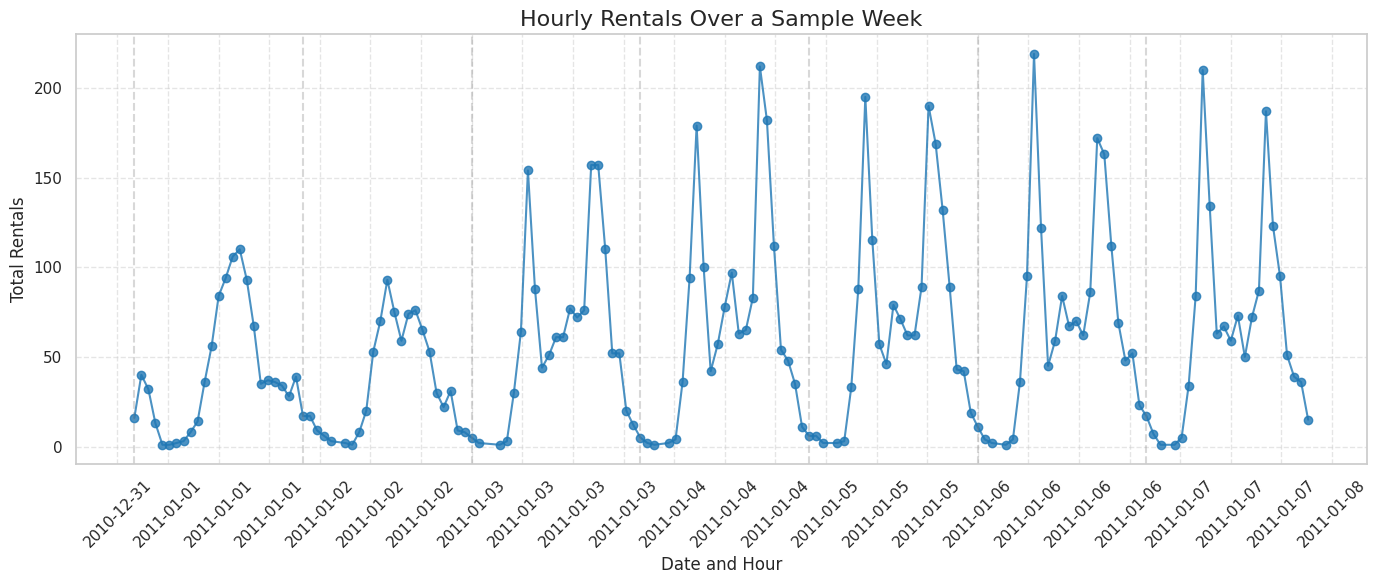

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine date and hour into a single datetime column
sample_week = hourly_df[hourly_df['dteday'].isin(hourly_df['dteday'].unique()[:7])].copy()
sample_week['datetime'] = pd.to_datetime(sample_week['dteday']) + pd.to_timedelta(sample_week['hr'], unit='h')

# Time series plot for a sample week
plt.figure(figsize=(14,6))
plt.plot(sample_week['datetime'], sample_week['total_bike_rental'], marker='o', linestyle='-', color='tab:blue', alpha=0.8)
plt.title('Hourly Rentals Over a Sample Week', fontsize=16)
plt.xlabel('Date and Hour', fontsize=12)
plt.ylabel('Total Rentals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show x-ticks for every 6 hours for clarity
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(28))
plt.xticks(rotation=45)

# Add vertical lines to separate days
for day in sample_week['datetime'].dt.normalize().unique():
    plt.axvline(day, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Casual user analysis on Hourly data

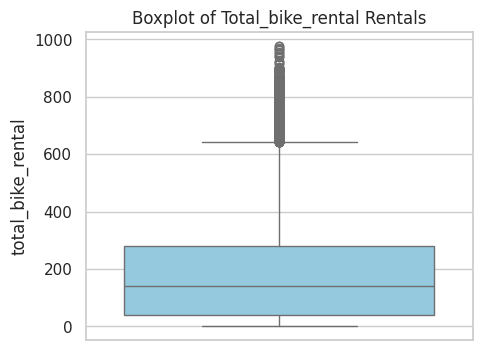

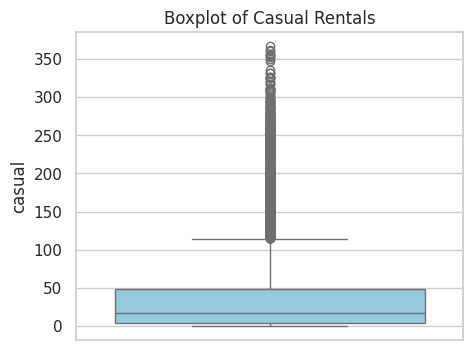

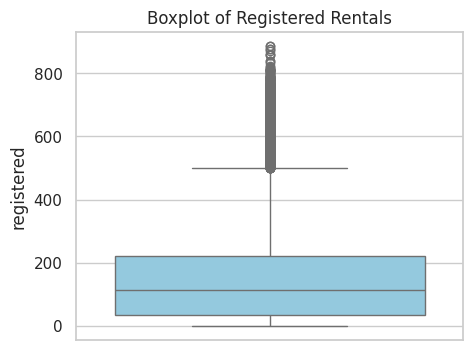

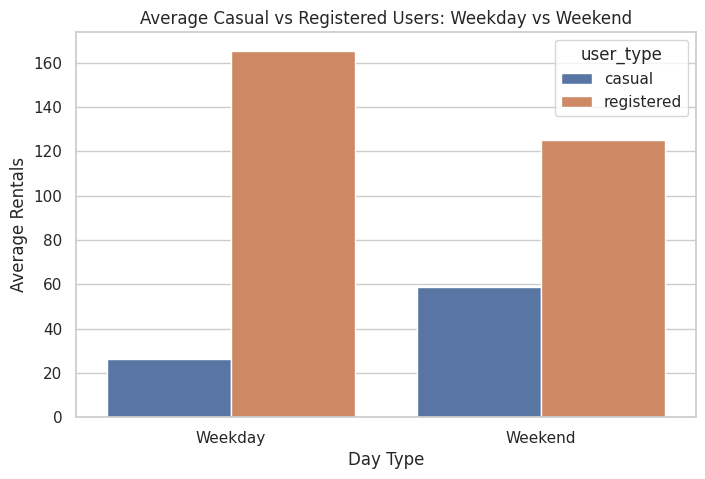

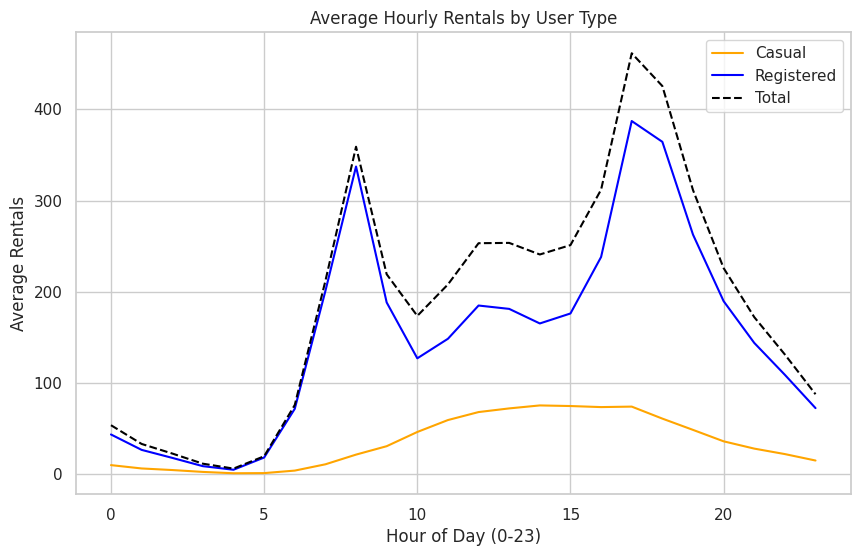

/tmp/ipython-input-489052519.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hourly_pattern = hourly_df.groupby(["hr", "workingday"])["total_bike_rental"].mean().reset_index()


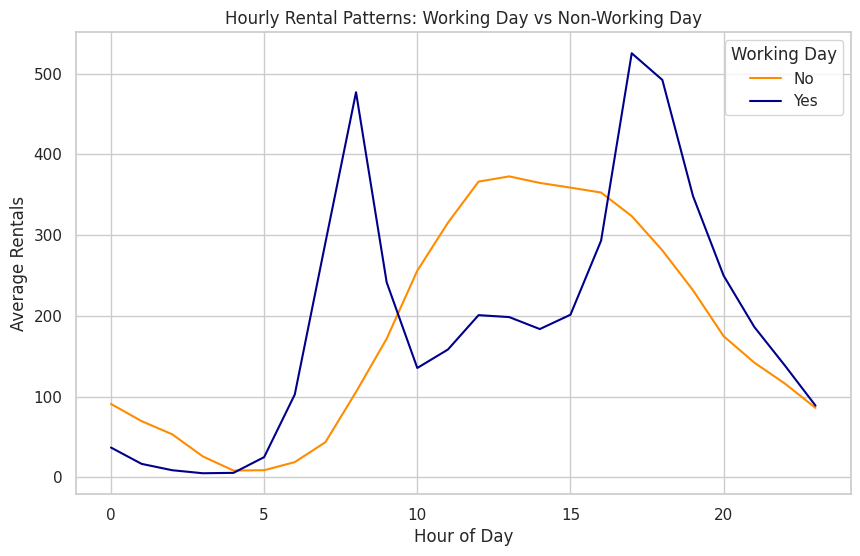

In [23]:
# Outliers - Boxplots for total, casual, and registered rentals
for col in ["total_bike_rental", "casual", "registered"]:
    plt.figure(figsize=(5, 4))
    sns.boxplot(y=hourly_df[col], color="skyblue")
    plt.title(f"Boxplot of {col.capitalize()} Rentals")
    plt.show()

# Create weekend flag
hourly_df["week_type"] = hourly_df["weekday"].apply(lambda x: "Weekend" if x in [6, 0] else "Weekday") # Use integer values for weekday

weekend_usage = hourly_df.groupby("week_type")[["casual", "registered"]].mean().reset_index()

# Melt data for plotting
weekend_usage_long = weekend_usage.melt(id_vars="week_type", var_name="user_type", value_name="avg_count")

# Plot average casual vs registered users on weekends vs weekdays
plt.figure(figsize=(8, 5))
sns.barplot(data=weekend_usage_long, x="week_type", y="avg_count", hue="user_type")
plt.title("Average Casual vs Registered Users: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Rentals")
plt.show()

hourly_avg = hourly_df.groupby("hr").agg({
    "casual": "mean",
    "registered": "mean",
    "total_bike_rental": "mean"
}).reset_index()
hourly_avg["hr"] = hourly_avg["hr"].astype(int)

# Plot hourly rentals by user type
plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_avg, x="hr", y="casual", label="Casual", color="orange")
sns.lineplot(data=hourly_avg, x="hr", y="registered", label="Registered", color="blue")
sns.lineplot(data=hourly_avg, x="hr", y="total_bike_rental", label="Total", color="black", linestyle="--")
plt.title("Average Hourly Rentals by User Type")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Average Rentals")
plt.legend()
plt.grid(True)
plt.show()

# Hourly Rentals by Working Day
hourly_df["workingday"] = hourly_df["workingday"].astype('category') # Convert to category dtype
hourly_df["workingday"] = hourly_df["workingday"].cat.reorder_categories([0, 1], ordered=True) # Use integer values for categories
hourly_df["workingday"] = hourly_df["workingday"].cat.rename_categories(["No", "Yes"]) # Rename categories for plotting

hourly_pattern = hourly_df.groupby(["hr", "workingday"])["total_bike_rental"].mean().reset_index()
hourly_pattern["hr"] = hourly_pattern["hr"].astype(int)

# Plot hourly rental patterns for working days vs non-working days
plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_pattern, x="hr", y="total_bike_rental", hue="workingday", palette=["darkorange", "darkblue"])
plt.title("Hourly Rental Patterns: Working Day vs Non-Working Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Rentals")
plt.legend(title="Working Day")
plt.grid(True)
plt.show()

## Outliers visualization and identification

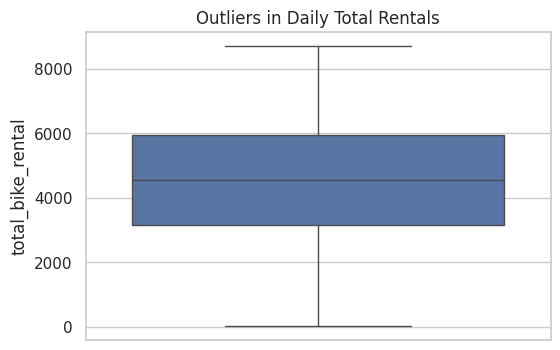

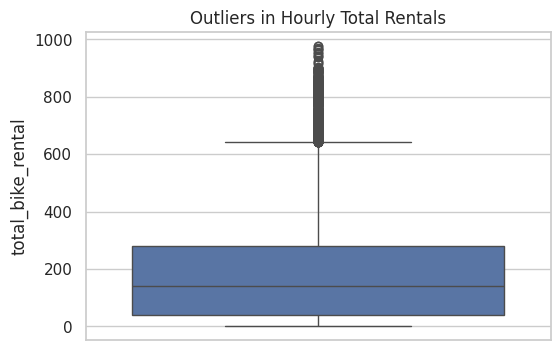

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daily data
plt.figure(figsize=(6,4))
sns.boxplot(y=daily_df['total_bike_rental'])
plt.title('Outliers in Daily Total Rentals')
plt.show()

# Hourly data
plt.figure(figsize=(6,4))
sns.boxplot(y=hourly_df['total_bike_rental'])
plt.title('Outliers in Hourly Total Rentals')
plt.show()

## Quantify outliers

In [25]:
# Identify outliers in daily and hourly total bike rental data using the IQR method
# For daily data
Q1 = daily_df['total_bike_rental'].quantile(0.25)
Q3 = daily_df['total_bike_rental'].quantile(0.75)
IQR = Q3 - Q1
outliers_daily = daily_df[(daily_df['total_bike_rental'] < Q1 - 1.5 * IQR) | (daily_df['total_bike_rental'] > Q3 + 1.5 * IQR)]
print("Number of outliers in daily data:", outliers_daily.shape[0])

# For hourly data
Q1 = hourly_df['total_bike_rental'].quantile(0.25)
Q3 = hourly_df['total_bike_rental'].quantile(0.75)
IQR = Q3 - Q1
outliers_hourly = hourly_df[(hourly_df['total_bike_rental'] < Q1 - 1.5 * IQR) | (hourly_df['total_bike_rental'] > Q3 + 1.5 * IQR)]
print("Number of outliers in hourly data:", outliers_hourly.shape[0])

Number of outliers in daily data: 0
Number of outliers in hourly data: 505


In [26]:
# Calculate the IQR and outlier bounds for daily total bike rentals, and display summary statistics
Q1 = daily_df['total_bike_rental'].quantile(0.25)
Q3 = daily_df['total_bike_rental'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Min: {daily_df['total_bike_rental'].min()}")
print(f"Max: {daily_df['total_bike_rental'].max()}")

Q1: 3152.0
Q3: 5956.0
IQR: 2804.0
Lower bound: -1054.0
Upper bound: 10162.0
Min: 22
Max: 8714


# Additional Findings

### Temperature Sensitivity

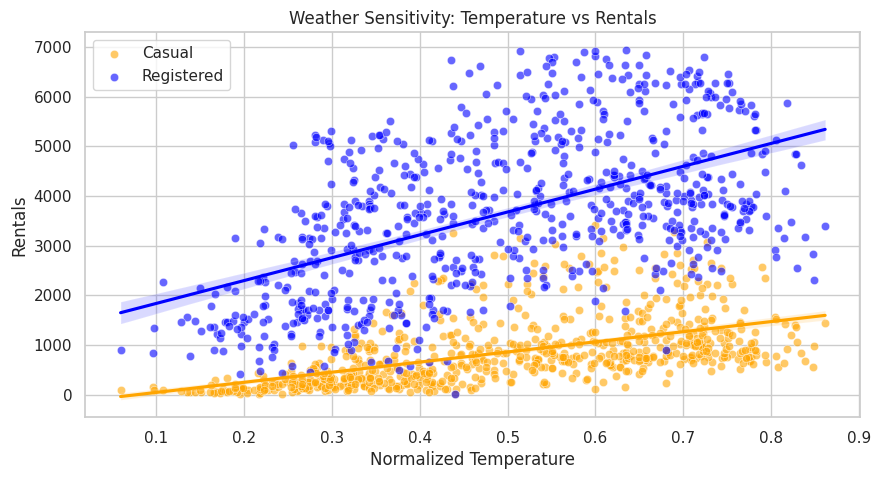

In [27]:
# Comparing how temperature affects casual and registered bike rentals
plt.figure(figsize=(10,5))
sns.scatterplot(x='temp', y='casual', data=daily_df, label='Casual', color='orange', alpha=0.6)
sns.scatterplot(x='temp', y='registered', data=daily_df, label='Registered', color='blue', alpha=0.6)
sns.regplot(x='temp', y='casual', data=daily_df, scatter=False, color='orange', label=None)
sns.regplot(x='temp', y='registered', data=daily_df, scatter=False, color='blue', label=None)
plt.title('Weather Sensitivity: Temperature vs Rentals')
plt.xlabel('Normalized Temperature')
plt.ylabel('Rentals')
plt.legend()
plt.show()

### Humidity Sensitivity

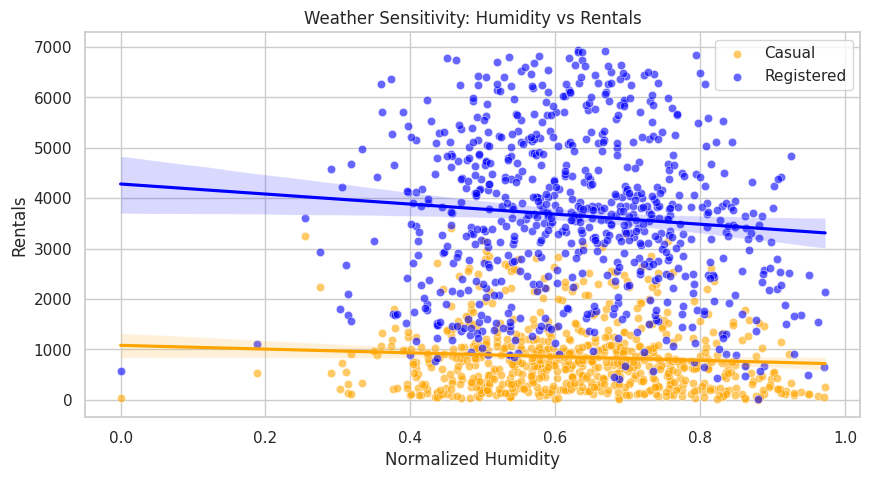

In [28]:
#Comparing how humidity affects casual and registered bike rentals
plt.figure(figsize=(10,5))
sns.scatterplot(x='hum', y='casual', data=daily_df, label='Casual', color='orange', alpha=0.6)
sns.scatterplot(x='hum', y='registered', data=daily_df, label='Registered', color='blue', alpha=0.6)
sns.regplot(x='hum', y='casual', data=daily_df, scatter=False, color='orange', label=None)
sns.regplot(x='hum', y='registered', data=daily_df, scatter=False, color='blue', label=None)
plt.title('Weather Sensitivity: Humidity vs Rentals')
plt.xlabel('Normalized Humidity')
plt.ylabel('Rentals')
plt.legend()
plt.show()

### Windspeed Sensitivity

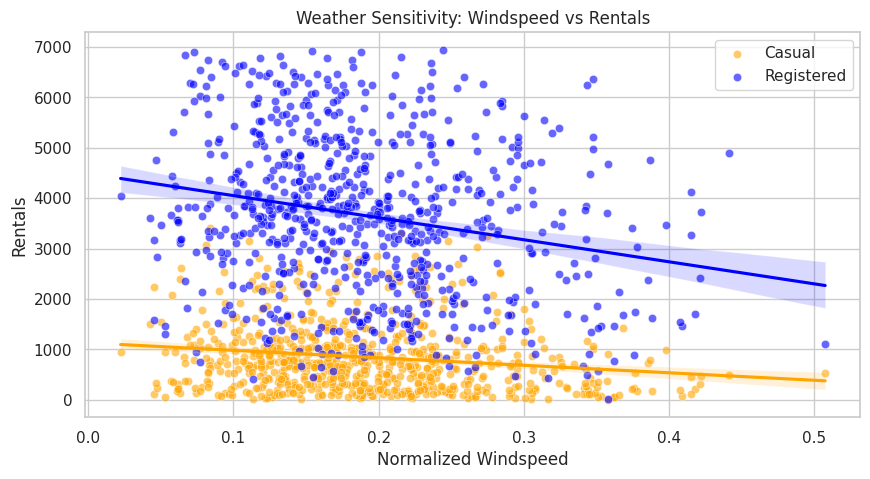

In [29]:
# Comparing how windspeed impacts casual and registered bike rentals
plt.figure(figsize=(10,5))
sns.scatterplot(x='windspeed', y='casual', data=daily_df, label='Casual', color='orange', alpha=0.6)
sns.scatterplot(x='windspeed', y='registered', data=daily_df, label='Registered', color='blue', alpha=0.6)
sns.regplot(x='windspeed', y='casual', data=daily_df, scatter=False, color='orange', label=None)
sns.regplot(x='windspeed', y='registered', data=daily_df, scatter=False, color='blue', label=None)
plt.title('Weather Sensitivity: Windspeed vs Rentals')
plt.xlabel('Normalized Windspeed')
plt.ylabel('Rentals')
plt.legend()
plt.show()

### Weather Situation Sensitivity

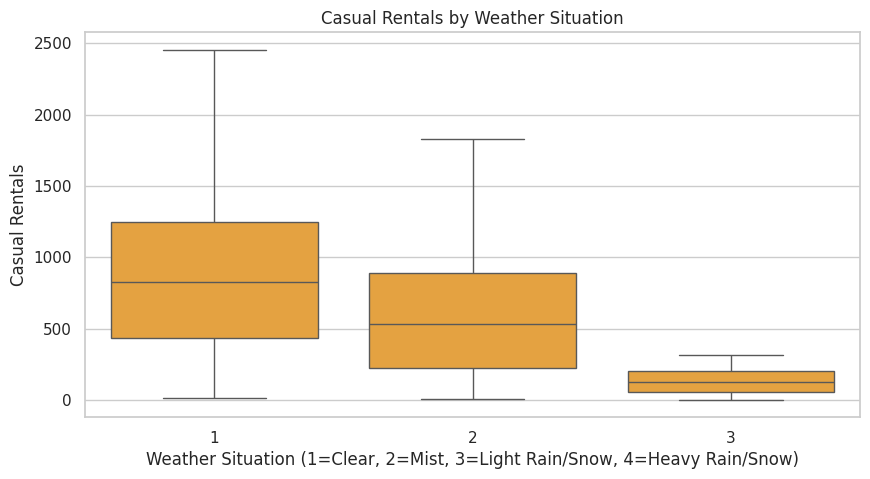

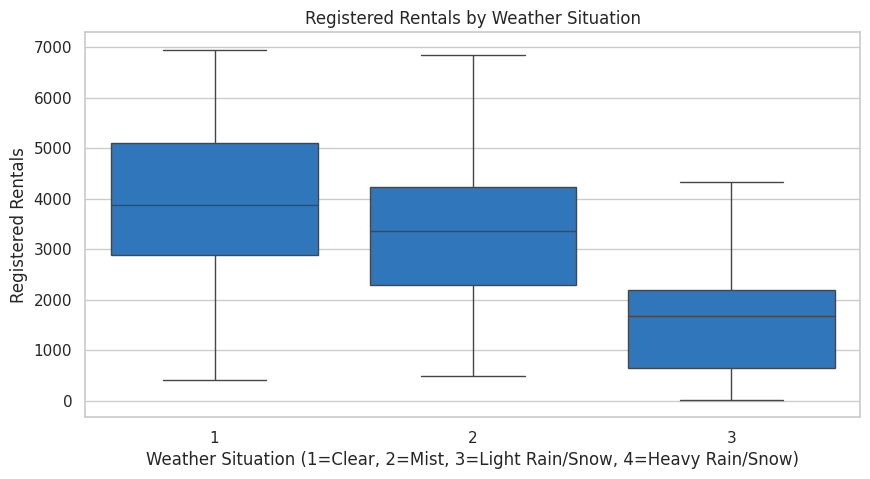

In [30]:
# Comparing how different weather situations affect casual bike rentals
plt.figure(figsize=(10,5))
sns.boxplot(x='weathersit', y='casual', data=daily_df, color='#FFA726', showfliers=False)  # Orange
plt.title('Casual Rentals by Weather Situation')
plt.xlabel('Weather Situation (1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain/Snow)')
plt.ylabel('Casual Rentals')
plt.show()

# Comparing how different weather situations affect registered bike rentals
plt.figure(figsize=(10,5))
sns.boxplot(x='weathersit', y='registered', data=daily_df, color='#1976D2', showfliers=False)  # Blue
plt.title('Registered Rentals by Weather Situation')
plt.xlabel('Weather Situation (1=Clear, 2=Mist, 3=Light Rain/Snow, 4=Heavy Rain/Snow)')
plt.ylabel('Registered Rentals')
plt.show()

# Feature Engineering

### Remove columns not required

In [31]:
# Remove columns not needed for modeling
cols_to_remove = ['dteday', 'instant', 'total_bike_rental', 'temp']
daily_df = daily_df.drop(columns=cols_to_remove)
hourly_df = hourly_df.drop(columns=cols_to_remove)

# Print columns
print("Columns in daily_df after dropping:", daily_df.columns.tolist())
print("Columns in hourly_df after dropping:", hourly_df.columns.tolist())

Columns in daily_df after dropping: ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'season_name', 'weather_condition_name', 'is_working_day', 'day_name', 'is_holiday', 'month_name', 'year_val']
Columns in hourly_df after dropping: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'season_name', 'weather_condition_name', 'is_working_day', 'day_name', 'is_holiday', 'month_name', 'year_val', 'week_type']


### One-hot encoding

In [32]:
# Convert categorical variables into binary columns (one-hot encoding)
# drop_first=True avoids multicollinearity by dropping the first category of each variable

day_df_encoded = pd.get_dummies(daily_df, columns=['season', 'weathersit', 'weekday', 'mnth'], drop_first=True)
hour_df_encoded = pd.get_dummies(hourly_df, columns=['season', 'weathersit', 'weekday', 'mnth', 'hr'], drop_first=True)

print("====== DAILY DATASET ===========\n \n")
display(day_df_encoded.head())
print("====== HOURLY DATASET =========== \n \n")
display(hour_df_encoded.head())


====== DAILY DATASET ===========
 



,yr,holiday,workingday,atemp,hum,windspeed,casual,registered,season_name,weather_condition_name,...,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12
0,0,0,0,0.363625,0.805833,0.160446,331,654,spring,Mist/Cloudy,...,False,False,False,False,False,False,False,False,False,False
1,0,0,0,0.353739,0.696087,0.248539,131,670,spring,Mist/Cloudy,...,False,False,False,False,False,False,False,False,False,False
2,0,0,1,0.189405,0.437273,0.248309,120,1229,spring,Clear,...,False,False,False,False,False,False,False,False,False,False
3,0,0,1,0.212122,0.590435,0.160296,108,1454,spring,Clear,...,False,False,False,False,False,False,False,False,False,False
4,0,0,1,0.229270,0.436957,0.186900,82,1518,spring,Clear,...,False,False,False,False,False,False,False,False,False,False


====== HOURLY DATASET =========== 
 



,yr,holiday,workingday,atemp,hum,windspeed,casual,registered,season_name,weather_condition_name,...,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23
0,0,0,No,0.2879,0.81,0.0,3,13,spring,Clear,...,False,False,False,False,False,False,False,False,False,False
1,0,0,No,0.2727,0.80,0.0,8,32,spring,Clear,...,False,False,False,False,False,False,False,False,False,False
2,0,0,No,0.2727,0.80,0.0,5,27,spring,Clear,...,False,False,False,False,False,False,False,False,False,False
3,0,0,No,0.2879,0.75,0.0,3,10,spring,Clear,...,False,False,False,False,False,False,False,False,False,False
4,0,0,No,0.2879,0.75,0.0,0,1,spring,Clear,...,False,False,False,False,False,False,False,False,False,False


### Creation of new features

### Creating `is_weekend`

In [33]:
# Create is_weekend feature for weekend that is 1 if the day is a weekend (Saturday or Sunday) and 0 otherwise
day_df_encoded['is_weekend'] = daily_df['weekday'].isin([0, 6]).astype(int)
hour_df_encoded['is_weekend'] = hourly_df['weekday'].isin([0, 6]).astype(int)

# Print columns
print(day_df_encoded[['is_weekend']].head())
print(hour_df_encoded[['is_weekend']].head())

   is_weekend
0           1
1           1
2           0
3           0
4           0
   is_weekend
0           1
1           1
2           1
3           1
4           1


### Plot Before Feature Engineering

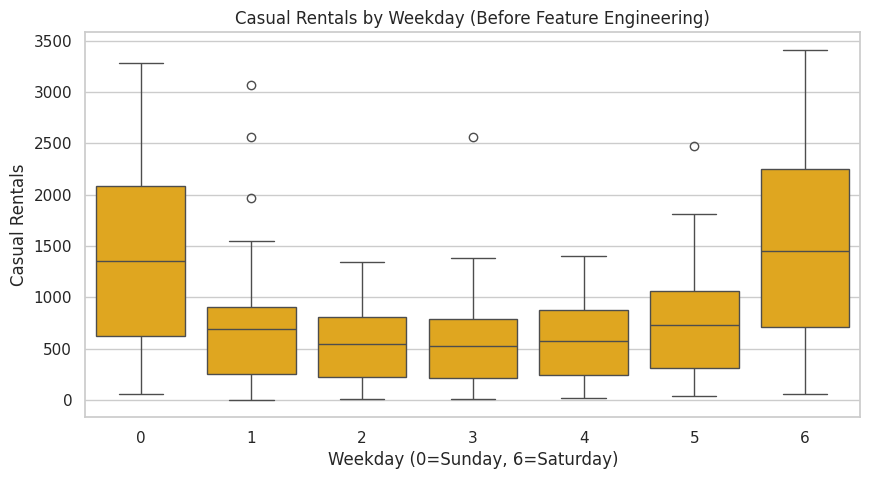

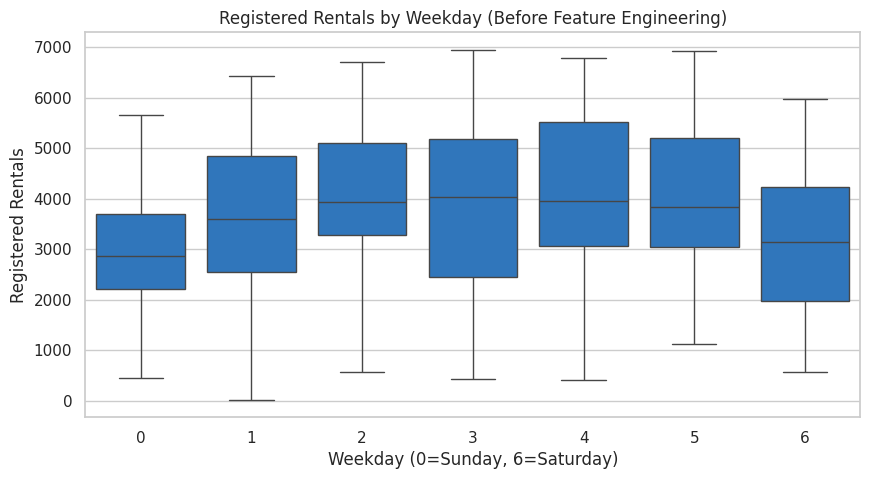

In [34]:
# Plot shows daily rentals by each day of the week. Patterns are not very distinct across days.
# Casual before feature engineering
sns.boxplot(x='weekday', y='casual', data=daily_df, color='#FFB300')
plt.title('Casual Rentals by Weekday (Before Feature Engineering)')
plt.xlabel('Weekday (0=Sunday, 6=Saturday)')
plt.ylabel('Casual Rentals')
plt.show()

# Registered before feature engineering
sns.boxplot(x='weekday', y='registered', data=daily_df, color='#1976D2')
plt.title('Registered Rentals by Weekday (Before Feature Engineering)')
plt.xlabel('Weekday (0=Sunday, 6=Saturday)')
plt.ylabel('Registered Rentals')
plt.show()

### Plot After Feature Engineering

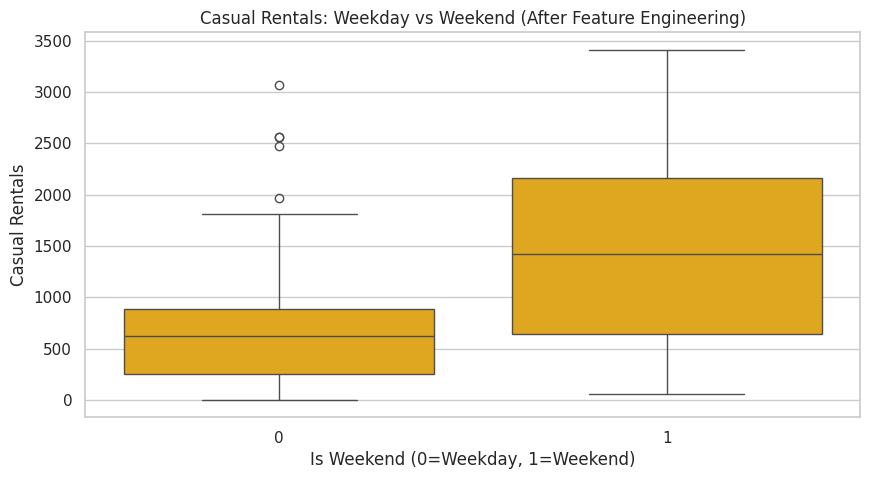

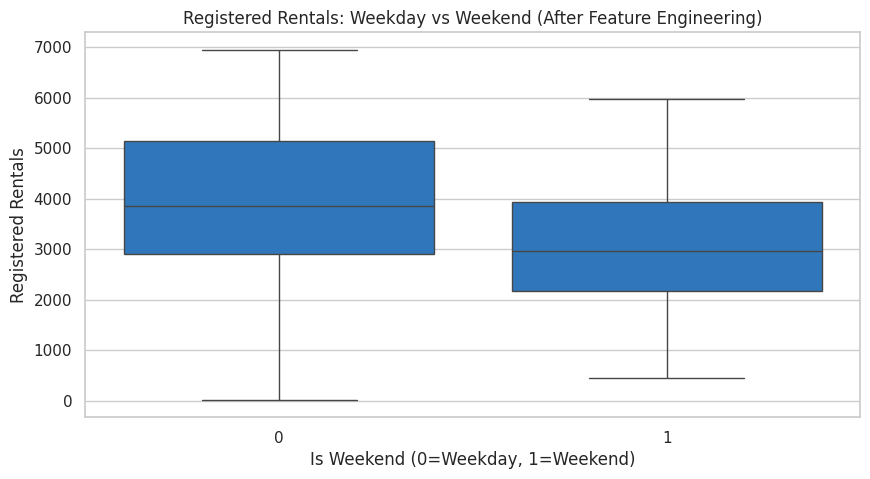

In [35]:
# Plot shows clear difference in rental patterns between weekdays and weekends.
# Casual after feature engineering
sns.boxplot(x='is_weekend', y='casual', data=day_df_encoded, color='#FFB300')
plt.title('Casual Rentals: Weekday vs Weekend (After Feature Engineering)')
plt.xlabel('Is Weekend (0=Weekday, 1=Weekend)')
plt.ylabel('Casual Rentals')
plt.show()

# Registered after feature engineering
sns.boxplot(x='is_weekend', y='registered', data=day_df_encoded, color='#1976D2')
plt.title('Registered Rentals: Weekday vs Weekend (After Feature Engineering)')
plt.xlabel('Is Weekend (0=Weekday, 1=Weekend)')
plt.ylabel('Registered Rentals')
plt.show()

Creating `part_of_day`

In [36]:
# Create part_of_day feature to categorize each hour into morning, afternoon, evening, or night (for hourly data)

def part_of_day(hr):
    if 6 <= hr < 12:
        return 'morning'
    elif 12 <= hr < 18:
        return 'afternoon'
    elif 18 <= hr < 24:
        return 'evening'
    else:
        return 'night'

# Apply the function to create the new feature
hourly_df['part_of_day'] = hourly_df['hr'].apply(part_of_day)

# Print to check the new column before encoding
print(hourly_df[['hr', 'part_of_day']].head(24))  # See a full day

# One-hot encode the new part_of_day feature
hour_df_encoded = pd.get_dummies(hourly_df, columns=['part_of_day'], drop_first=True)

# Print to check the new encoded columns
print(hour_df_encoded.filter(like='part_of_day').head(24))

    hr part_of_day
0    0       night
1    1       night
2    2       night
3    3       night
4    4       night
5    5       night
6    6     morning
7    7     morning
8    8     morning
9    9     morning
10  10     morning
11  11     morning
12  12   afternoon
13  13   afternoon
14  14   afternoon
15  15   afternoon
16  16   afternoon
17  17   afternoon
18  18     evening
19  19     evening
20  20     evening
21  21     evening
22  22     evening
23  23     evening
    part_of_day_evening  part_of_day_morning  part_of_day_night
0                 False                False               True
1                 False                False               True
2                 False                False               True
3                 False                False               True
4                 False                False               True
5                 False                False               True
6                 False                 True              False
7            

### Plot Before Feature Engineering

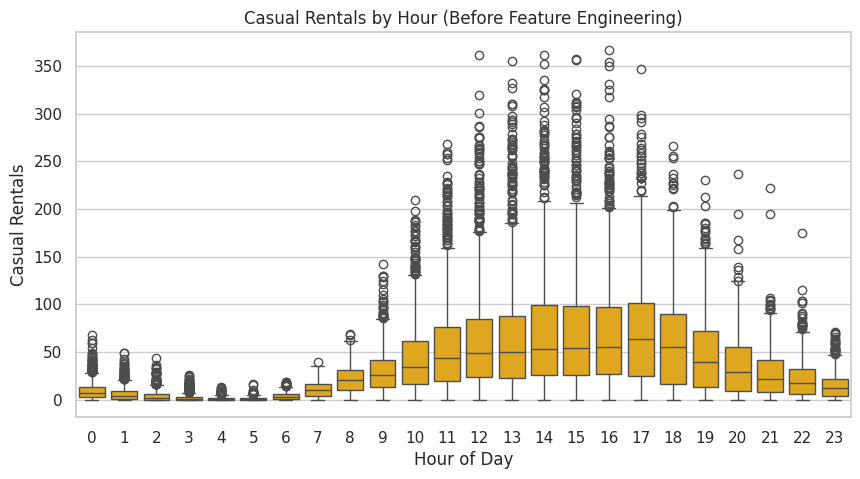

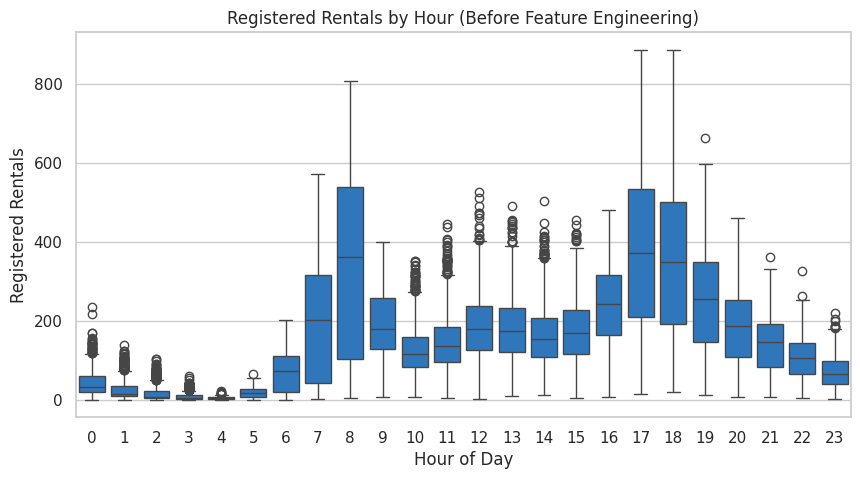

In [37]:
# Shows hourly rental patterns before feature engineering (by each hour)
# Casual rentals by hour
plt.figure(figsize=(10,5))
sns.boxplot(x='hr', y='casual', data=hourly_df, color='#FFB300')
plt.title('Casual Rentals by Hour (Before Feature Engineering)')
plt.xlabel('Hour of Day')
plt.ylabel('Casual Rentals')
plt.show()

# Registered rentals by hour
plt.figure(figsize=(10,5))
sns.boxplot(x='hr', y='registered', data=hourly_df, color='#1976D2')
plt.title('Registered Rentals by Hour (Before Feature Engineering)')
plt.xlabel('Hour of Day')
plt.ylabel('Registered Rentals')
plt.show()

### Plot After Feature Engineering

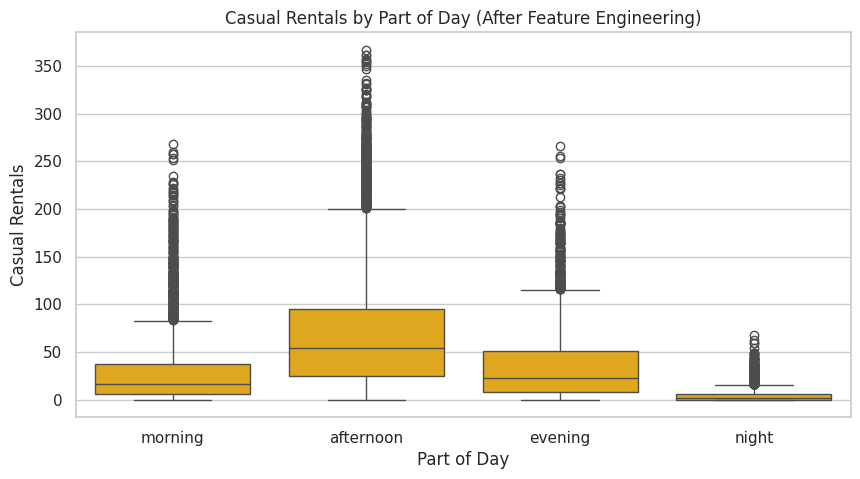

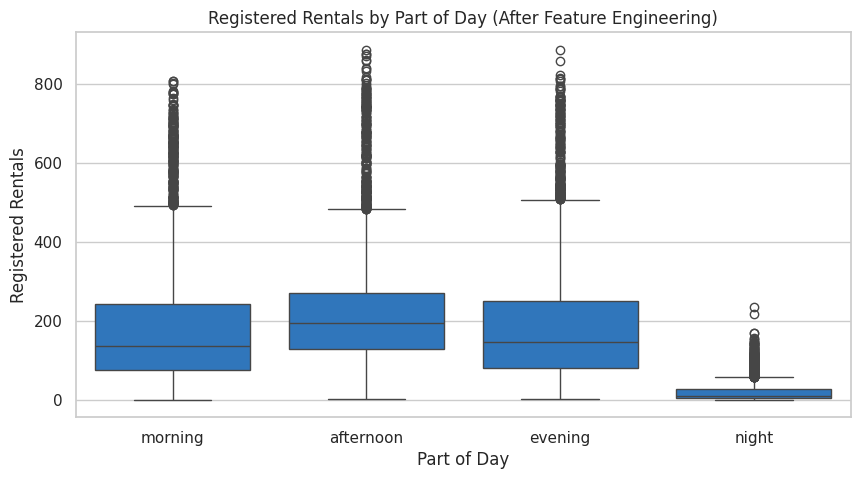

In [38]:
# Shows rental patterns after grouping hours into part of day (after feature engineering)
# Casual rentals by part of day
plt.figure(figsize=(10,5))
sns.boxplot(x='part_of_day', y='casual', data=hourly_df, order=['morning', 'afternoon', 'evening', 'night'], color='#FFB300')
plt.title('Casual Rentals by Part of Day (After Feature Engineering)')
plt.xlabel('Part of Day')
plt.ylabel('Casual Rentals')
plt.show()

# Registered rentals by part of day
plt.figure(figsize=(10,5))
sns.boxplot(x='part_of_day', y='registered', data=hourly_df, order=['morning', 'afternoon', 'evening', 'night'], color='#1976D2')
plt.title('Registered Rentals by Part of Day (After Feature Engineering)')
plt.xlabel('Part of Day')
plt.ylabel('Registered Rentals')
plt.show()

Creating `is_peak_hour`

In [39]:
# Create peak_hour feature: 1 if hour is in peak hours (7-9 AM, 5-7 PM), else 0
hour_df_encoded['is_peak_hour'] = hourly_df['hr'].isin([7,8,9,17,18,19]).astype(int)
hourly_df['is_peak_hour'] = hourly_df['hr'].isin([7,8,9,17,18,19]).astype(int)

print(hour_df_encoded[['is_peak_hour']].head(20))
print(hourly_df[['is_peak_hour']].head(20))

    is_peak_hour
0              0
1              0
2              0
3              0
4              0
5              0
6              0
7              1
8              1
9              1
10             0
11             0
12             0
13             0
14             0
15             0
16             0
17             1
18             1
19             1
    is_peak_hour
0              0
1              0
2              0
3              0
4              0
5              0
6              0
7              1
8              1
9              1
10             0
11             0
12             0
13             0
14             0
15             0
16             0
17             1
18             1
19             1


### Plot After Feature Engineering

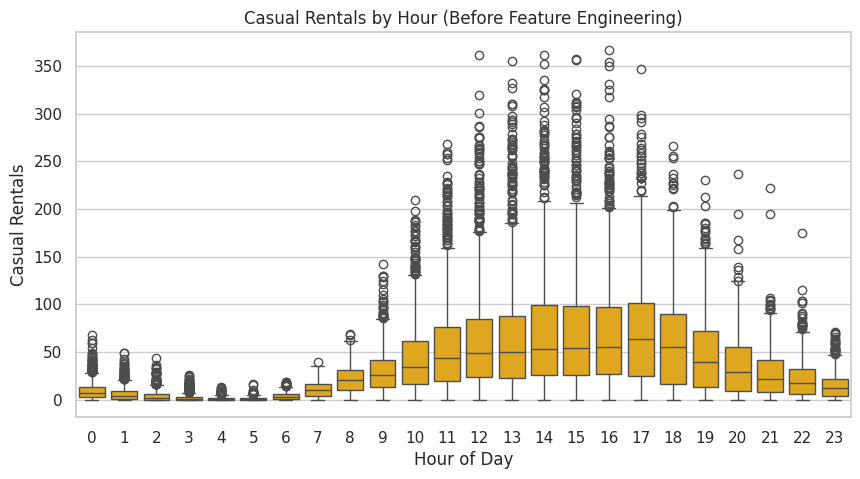

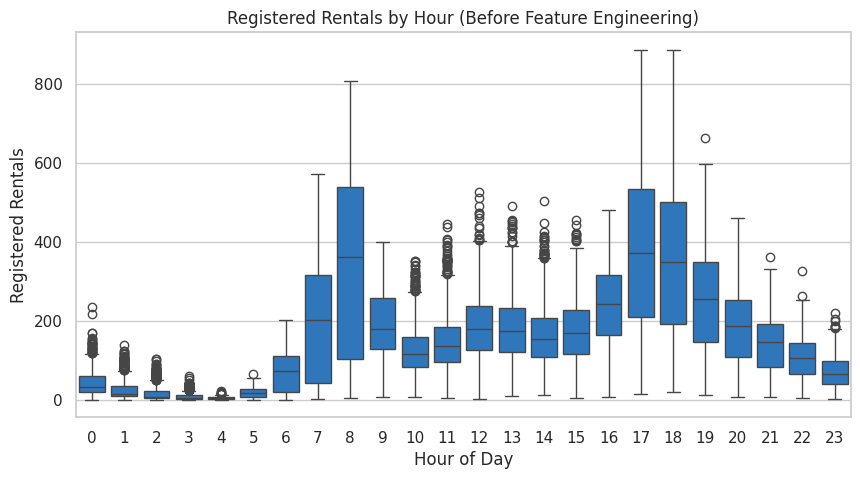

In [40]:
# Shows rental patterns by each hour (before feature engineering)
# Casual rentals by hour
plt.figure(figsize=(10,5))
sns.boxplot(x='hr', y='casual', data=hourly_df, color='#FFB300')
plt.title('Casual Rentals by Hour (Before Feature Engineering)')
plt.xlabel('Hour of Day')
plt.ylabel('Casual Rentals')
plt.show()

# Registered rentals by hour
plt.figure(figsize=(10,5))
sns.boxplot(x='hr', y='registered', data=hourly_df, color='#1976D2')
plt.title('Registered Rentals by Hour (Before Feature Engineering)')
plt.xlabel('Hour of Day')
plt.ylabel('Registered Rentals')
plt.show()

### Plot After Feature Engineering

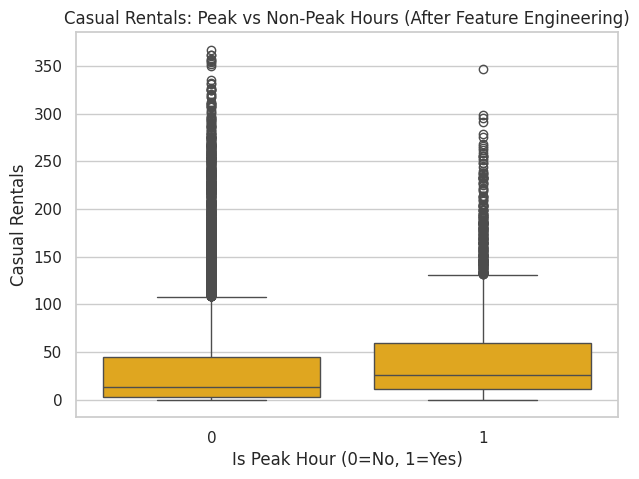

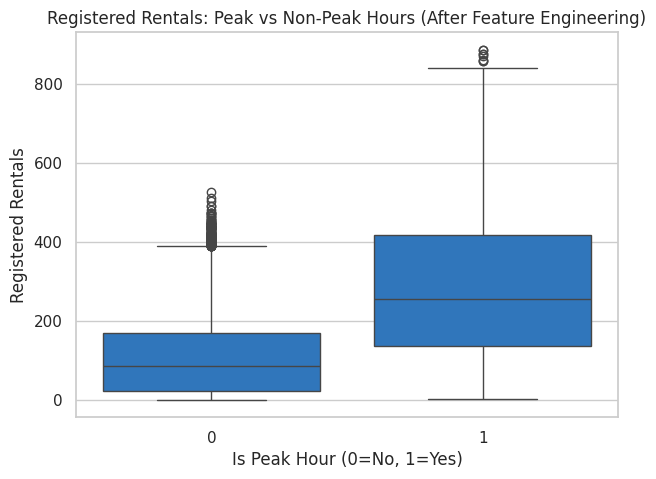

In [41]:
# Shows rental patterns grouped by peak vs non-peak hours (after feature engineering)
# Casual rentals by peak hour
plt.figure(figsize=(7,5))
sns.boxplot(x='is_peak_hour', y='casual', data=hourly_df, color='#FFB300')
plt.title('Casual Rentals: Peak vs Non-Peak Hours (After Feature Engineering)')
plt.xlabel('Is Peak Hour (0=No, 1=Yes)')
plt.ylabel('Casual Rentals')
plt.show()

# Registered rentals by peak hour
plt.figure(figsize=(7,5))
sns.boxplot(x='is_peak_hour', y='registered', data=hourly_df, color='#1976D2')
plt.title('Registered Rentals: Peak vs Non-Peak Hours (After Feature Engineering)')
plt.xlabel('Is Peak Hour (0=No, 1=Yes)')
plt.ylabel('Registered Rentals')
plt.show()

### Transform non numerical features for daily data

In [42]:
# Convert all boolean columns to binary (0/1)
bool_cols = day_df_encoded.select_dtypes(include=['bool']).columns
day_df_encoded[bool_cols] = day_df_encoded[bool_cols].astype(int)

# Print data after conversion from boolean to binary
print(day_df_encoded.head())

# List of columns to remove (e.g., date, names, or any non-feature columns)
cols_to_remove = ['dteday', 'season_name', 'weather_condition_name', 'is_working_day',
                  'day_name', 'is_holiday', 'month_name', 'year_val']

# Remove these columns if they exist in the DataFrame
day_df_train = day_df_encoded.drop(columns=[col for col in cols_to_remove if col in day_df_encoded.columns])

# Check for any remaining non-numeric columns
non_numeric_cols = day_df_train.select_dtypes(exclude=['number']).columns
print(non_numeric_cols)

   yr  holiday  workingday     atemp       hum  windspeed  casual  registered  \
0   0        0           0  0.363625  0.805833   0.160446     331         654   
1   0        0           0  0.353739  0.696087   0.248539     131         670   
2   0        0           1  0.189405  0.437273   0.248309     120        1229   
3   0        0           1  0.212122  0.590435   0.160296     108        1454   
4   0        0           1  0.229270  0.436957   0.186900      82        1518   

  season_name weather_condition_name  ... mnth_4 mnth_5 mnth_6 mnth_7 mnth_8  \
0      spring            Mist/Cloudy  ...      0      0      0      0      0   
1      spring            Mist/Cloudy  ...      0      0      0      0      0   
2      spring                  Clear  ...      0      0      0      0      0   
3      spring                  Clear  ...      0      0      0      0      0   
4      spring                  Clear  ...      0      0      0      0      0   

   mnth_9  mnth_10  mnth_11  mnt

### Transform non numerical features for hourly data

In [43]:
# Convert all boolean columns to binary (0/1) for modeling compatibility
bool_cols = hour_df_encoded.select_dtypes(include=['bool']).columns
hour_df_encoded[bool_cols] = hour_df_encoded[bool_cols].astype(int)

# Print data after conversion from boolean to binary
print(day_df_encoded.head())

# Remove columns that are not needed for modeling (such as date, descriptive names, or engineered features not used)
cols_to_remove = [
    'dteday', 'season_name', 'weather_condition_name', 'is_working_day',
    'day_name', 'is_holiday', 'month_name', 'year_val', 'workingday', 'week_type',
    'part_of_day'
]
# Drop only those columns that exist in the DataFrame to avoid errors
cols_to_remove_existing = [col for col in cols_to_remove if col in hour_df_encoded.columns]
hour_df_train = hour_df_encoded.drop(columns=cols_to_remove_existing)

# Check for any remaining non-numeric columns to ensure the dataset is ready for modeling
non_numeric_cols_h = hour_df_train.select_dtypes(exclude=['number']).columns
print(non_numeric_cols_h)

   yr  holiday  workingday     atemp       hum  windspeed  casual  registered  \
0   0        0           0  0.363625  0.805833   0.160446     331         654   
1   0        0           0  0.353739  0.696087   0.248539     131         670   
2   0        0           1  0.189405  0.437273   0.248309     120        1229   
3   0        0           1  0.212122  0.590435   0.160296     108        1454   
4   0        0           1  0.229270  0.436957   0.186900      82        1518   

  season_name weather_condition_name  ... mnth_4 mnth_5 mnth_6 mnth_7 mnth_8  \
0      spring            Mist/Cloudy  ...      0      0      0      0      0   
1      spring            Mist/Cloudy  ...      0      0      0      0      0   
2      spring                  Clear  ...      0      0      0      0      0   
3      spring                  Clear  ...      0      0      0      0      0   
4      spring                  Clear  ...      0      0      0      0      0   

   mnth_9  mnth_10  mnth_11  mnt

# Training the model

### Split the dataset into training and testing

### Split Daily data for LSTM

In [44]:
# ====================================================
# Prepare and Split Daily Dataset (Chronological)
# ====================================================

# Create total rentals if not already present
day_df_train['total_bike_rental'] = day_df_train['registered'] + day_df_train['casual']

# Define features and target
X_daily = day_df_train.drop(columns=['total_bike_rental'])
y_daily = day_df_train['total_bike_rental']

# Chronological split (first 80% = train, last 20% = test)
split_idx_day = int(len(X_daily) * 0.8)

X_train_d = X_daily.iloc[:split_idx_day]
X_test_d  = X_daily.iloc[split_idx_day:]
y_train_d = y_daily.iloc[:split_idx_day]
y_test_d  = y_daily.iloc[split_idx_day:]

print("Daily Data Split Completed:")
print(f"Train set: {X_train_d.shape}, Test set: {X_test_d.shape}")

Daily Data Split Completed:
Train set: (584, 31), Test set: (147, 31)


### Split hourly data for LSTM

In [45]:
# ====================================================
# Prepare and Split Hourly Dataset (Chronological)
# ====================================================

# Create target variable (Option A: total bike rental)
hour_df_train['total_bike_rental'] = hour_df_train['registered'] + hour_df_train['casual']

# Define features and target
X_hourly = hour_df_train.drop(columns=['total_bike_rental'])
y_hourly = hour_df_train['total_bike_rental']

# Chronological split (first 80% = train, last 20% = test)
split_idx_hour = int(len(X_hourly) * 0.8)

X_train_h = X_hourly.iloc[:split_idx_hour]
X_test_h  = X_hourly.iloc[split_idx_hour:]
y_train_h = y_hourly.iloc[:split_idx_hour]
y_test_h  = y_hourly.iloc[split_idx_hour:]

print("Hourly Data Split Completed:")
print(f"Train set: {X_train_h.shape}, Test set: {X_test_h.shape}")

Hourly Data Split Completed:
Train set: (13903, 16), Test set: (3476, 16)


### LSTM Model Builder and training

In [46]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ------------------- Load datasets -------------------
df_hourly = pd.read_csv("hour.csv", parse_dates=['dteday'])
df_daily = pd.read_csv("day.csv", parse_dates=['dteday'])

# Ensure necessary columns exist
for col in ['dteday', 'casual', 'registered']:
    if col not in df_hourly.columns:
        raise ValueError(f"{col} not in hourly dataframe")
    if col not in df_daily.columns:
        raise ValueError(f"{col} not in daily dataframe")

# ------------------- Sequence preparation -------------------
def prepare_sequences(df, target_col, sequence_length=24):
    df_numeric = df.select_dtypes(include=[np.number])
    X = df_numeric.drop(columns=[target_col]).values
    y = df_numeric[[target_col]].values

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    X_seq, y_seq = [], []
    for i in range(sequence_length, len(X_scaled)):
        X_seq.append(X_scaled[i-sequence_length:i])
        y_seq.append(y_scaled[i])

    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

# ------------------- LSTM model builder -------------------
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ------------------- Hourly Data Training -------------------
sequence_length_hr = 24

# Casual
X_hr_c, y_hr_c, scalerX_hr_c, scalerY_hr_c = prepare_sequences(df_hourly, 'casual', sequence_length_hr)
split = int(len(X_hr_c)*0.8)
X_train_hr_c, X_test_hr_c = X_hr_c[:split], X_hr_c[split:]
y_train_hr_c, y_test_hr_c = y_hr_c[:split], y_hr_c[split:]

model_hr_c = build_lstm_model(X_train_hr_c.shape[1:])
history_hr_c = model_hr_c.fit(X_train_hr_c, y_train_hr_c, epochs=20, batch_size=32, verbose=1)

# Registered
X_hr_r, y_hr_r, scalerX_hr_r, scalerY_hr_r = prepare_sequences(df_hourly, 'registered', sequence_length_hr)
X_train_hr_r, X_test_hr_r = X_hr_r[:split], X_hr_r[split:]
y_train_hr_r, y_test_hr_r = y_hr_r[:split], y_hr_r[split:]

model_hr_r = build_lstm_model(X_train_hr_r.shape[1:])
history_hr_r = model_hr_r.fit(X_train_hr_r, y_train_hr_r, epochs=20, batch_size=32, verbose=1)

# ------------------- Daily Data Training -------------------
sequence_length_d = 7

# Casual
X_d_c, y_d_c, scalerX_d_c, scalerY_d_c = prepare_sequences(df_daily, 'casual', sequence_length_d)
split = int(len(X_d_c)*0.8)
X_train_d_c, X_test_d_c = X_d_c[:split], X_d_c[split:]
y_train_d_c, y_test_d_c = y_d_c[:split], y_d_c[split:]

model_d_c = build_lstm_model(X_train_d_c.shape[1:])
history_d_c = model_d_c.fit(X_train_d_c, y_train_d_c, epochs=25, batch_size=16, verbose=1)

# Registered
X_d_r, y_d_r, scalerX_d_r, scalerY_d_r = prepare_sequences(df_daily, 'registered', sequence_length_d)
X_train_d_r, X_test_d_r = X_d_r[:split], X_d_r[split:]
y_train_d_r, y_test_d_r = y_d_r[:split], y_d_r[split:]

model_d_r = build_lstm_model(X_train_d_r.shape[1:])
history_d_r = model_d_r.fit(X_train_d_r, y_train_d_r, epochs=25, batch_size=16, verbose=1)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 0.0111
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0038
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0029
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0026
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0022
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0020
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0018
Epoch 8/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0018
Epoch 9/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0019
Epoch 10/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0019
Epoch 11/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0017
Epoch 12/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0016
Epoch 13/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0017
Epoch 14/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0016
Epoch 15/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/ste

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0210
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0087
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0048
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0030
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.0028
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0025
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0023
Epoch 8/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0021
Epoch 9/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0020
Epoch 10/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0020
Epoch 11/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0018
Epoch 12/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0017
Epoch 13/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0018
Epoch 14/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0016
Epoch 15/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0404
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0243
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0225
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0204
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0175
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0183
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0181
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0154
Epoch 9/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0158
Epoch 10/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0151
Epoch 11/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0143
Epoch 12/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0128
Epoch 13/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0127
Epoch 14/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134
Epoch 15/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0124
Epoch 16/25
37/37 ━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0955
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0207
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0191
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0161
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0169
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0137
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0129
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0136
Epoch 9/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0123
Epoch 10/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0127
Epoch 11/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0122
Epoch 12/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0107
Epoch 13/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0118
Epoch 14/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0117
Epoch 15/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130
Epoch 16/25
37/37 ━━━━━━━━━━━━

## Random Forest regressor to predict total bike rental



## Random Forest Regressor functions

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

def run_rf_grid_search(X_train, y_train, param_grid=None, cv=5, scoring="r2", verbose=2):
    """
    Runs GridSearchCV for RandomForestRegressor, prints results,
    and returns the best model created with best_params_.
    """

    # Default param grid if none provided
    if param_grid is None:
        param_grid = {
            'n_estimators': [200, 300],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt', 'log2']
        }

    # Base model
    rf = RandomForestRegressor(random_state=42)

    # Grid Search
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=verbose
    )

    # Fit grid search
    grid_search.fit(X_train, y_train)

    # Extract best parameters
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    print("\n\n Best Parameters Found:", best_params)
    print("\n\n Best Cross-Validation R²:", best_score)

    print("\n\n")
    # Build new model using the best parameters
    best_model = RandomForestRegressor(
        n_estimators=best_params['n_estimators'],
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=42
    )

    return best_model, best_params, best_score, grid_search


def plot_shap_summary(model, X_test):
    """
    Computes SHAP values for a tree-based model
    and displays a SHAP summary plot.
    """

    # Create SHAP explainer
    explainer = shap.TreeExplainer(model)

    # Compute SHAP values
    shap_values = explainer.shap_values(X_test)

    # Plot summary
    shap.summary_plot(shap_values, X_test)


def plot_feature_importance(model, X_train, y_train, top_n=10):
    """
    Function used to plot the top 10 most important
    features for a Random Forest model.
    """

    # Fit the model on the provided training set
    model.fit(X_train, y_train)

    # Extract importances
    importances = model.feature_importances_
    feature_names = X_train.columns

    # Create DataFrame and sort
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values(by="importance", ascending=False)

    # Select top N features
    top_features = feat_imp.head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(top_features["feature"], top_features["importance"])
    plt.xlabel("Importance Score")
    plt.title(f"Top {top_n} Most Important Features (Random Forest)")
    plt.gca().invert_yaxis()  # Most important on top
    plt.tight_layout()
    plt.show()



def plot_actual_vs_predicted(model, X_test, y_test, X_train, y_train):
    """
    Creates an Actual vs Predicted scatter plot for Random Forest model
    and prints MSE, RMSE, MAE.
    """

    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Plot
    plt.figure(figsize=(8, 6))

    plt.scatter(y_test, y_pred, alpha=0.6, label="Predicted vs Actual")

    # Perfect prediction line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label="Perfect Prediction (y = x)"
    )

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs Predicted Values")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Error metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    mean_actual = np.mean(y_test)
    error_rate = (rmse / mean_actual) * 100
    print(f"MSE  : {mse}")
    print(f"RMSE : {rmse}")
    print(f"MAE  : {mae}")
    print("\n")
    print(f"Error Rate: {error_rate:.2f}%")


## Split daily data for random forest training

In [70]:
from sklearn.model_selection import train_test_split
# Features
X = day_df_train.drop(columns=['total_bike_rental'])
# Variable of interest
y = day_df_train["total_bike_rental"]

# Split the data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Random Forest Regressor for total bike rental

In [71]:
best_rf_model, best_params, best_cv_r2, grid_obj = run_rf_grid_search(X_train, y_train)
# Fit the model here after finding the best parameters
best_rf_model.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


 Best Parameters Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


 Best Cross-Validation R²: 0.9606050430680042





RandomForestRegressor(max_features='sqrt', n_estimators=300, random_state=42)

## Shap summary for total bike rental

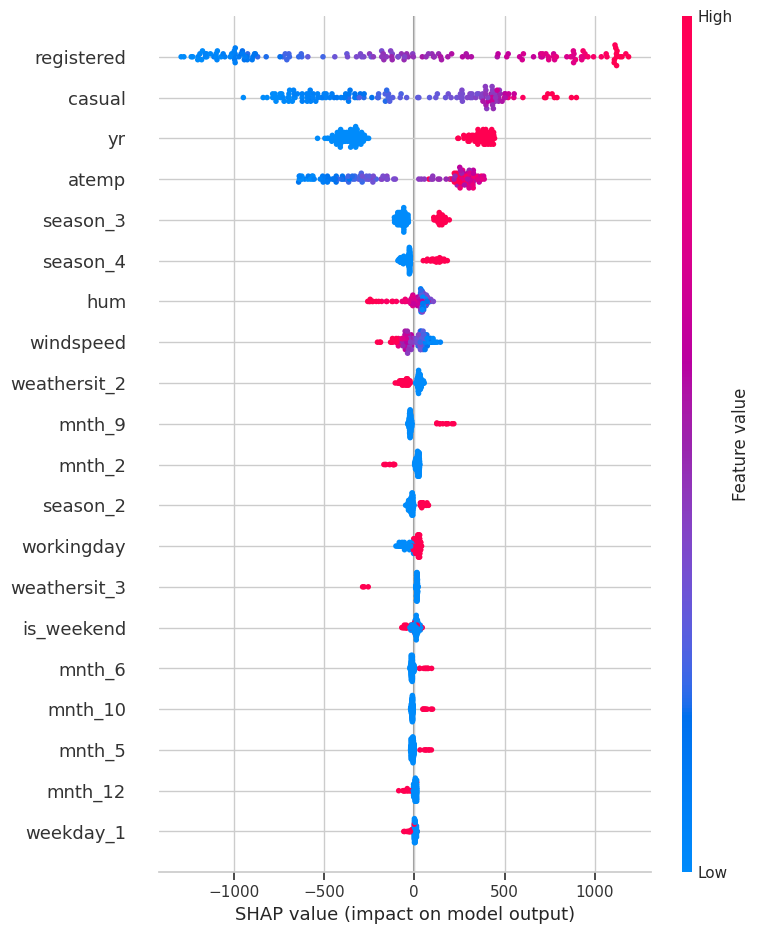

In [50]:
plot_shap_summary(best_rf_model, X_test)

## Feature importance for total bike rental

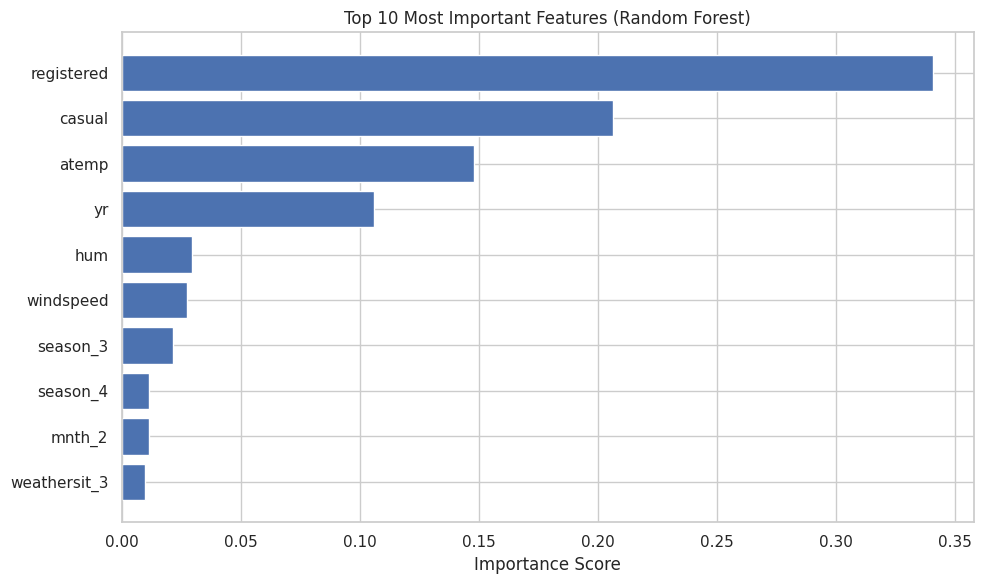

In [51]:
plot_feature_importance(best_rf_model, X_train, y_train)

## Accuracy and residual plots for total bike rental

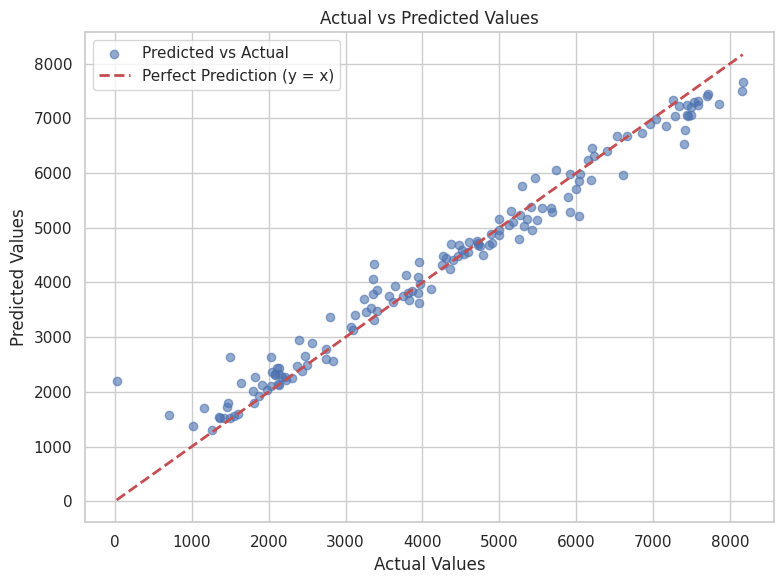

MSE  : 135160.3801277589
RMSE : 367.6416463456757
MAE  : 250.68434240362814


Error Rate: 8.59%


In [72]:
plot_actual_vs_predicted(best_rf_model, X_test, y_test, X_train, y_train)

## Random Forest Regressor for registered users

In [73]:
from sklearn.model_selection import train_test_split
# Features
X = day_df_train.drop(columns=['total_bike_rental', 'casual', 'registered'])
# Variable of interest
y = day_df_train["registered"]
# Split the data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Training random forest regressor for registered users

In [74]:
best_rf_model, best_params, best_cv_r2, grid_obj = run_rf_grid_search(X_train, y_train)
# Fit the model here after finding the best parameters
best_rf_model.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


 Best Parameters Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


 Best Cross-Validation R²: 0.8355717912800525





RandomForestRegressor(max_features='sqrt', n_estimators=300, random_state=42)

### Shap summary for registered users

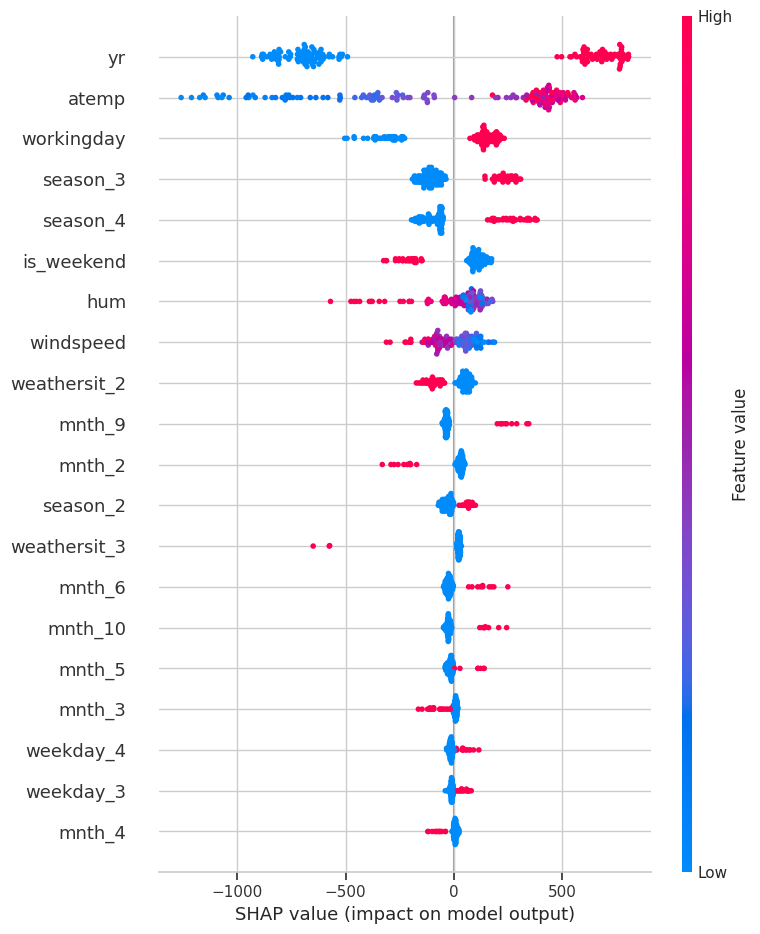

In [55]:
plot_shap_summary(best_rf_model, X_test)

### Feature importance for registered users

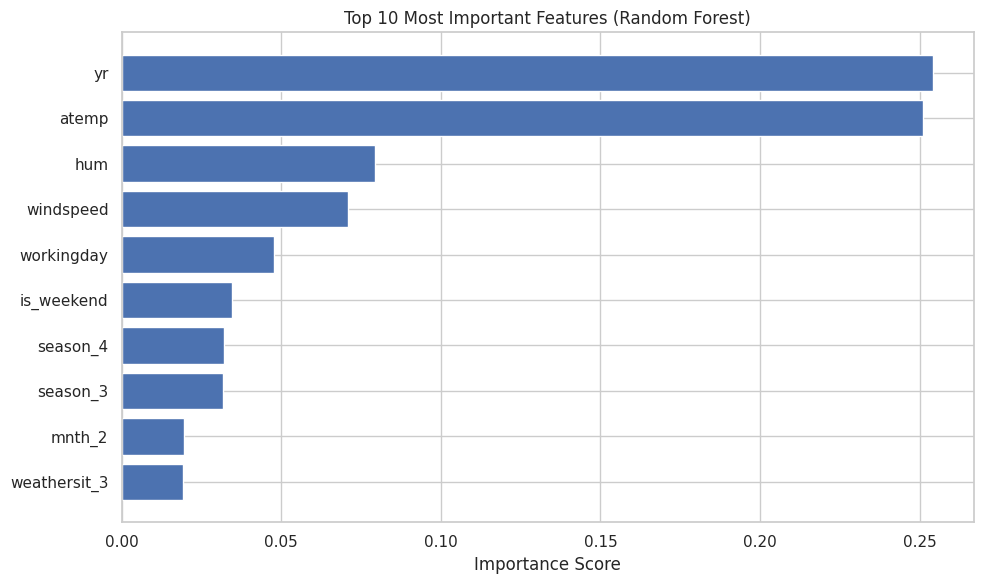

In [56]:
plot_feature_importance(best_rf_model, X_train, y_train)

### Accuracy and residual plots for casual users

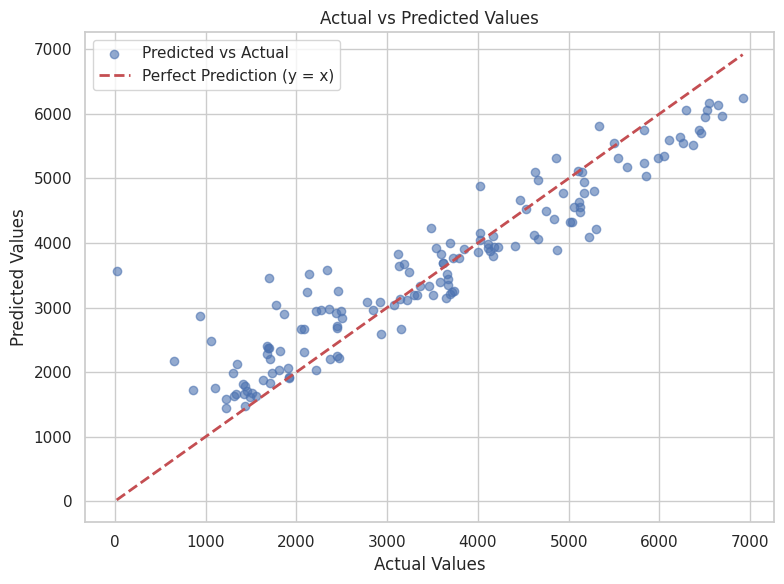

MSE  : 410565.2090870748
RMSE : 640.7536258867949
MAE  : 468.82702947845803


Error Rate: 18.26%


In [75]:
plot_actual_vs_predicted(best_rf_model, X_test, y_test, X_train, y_train)

### Important features

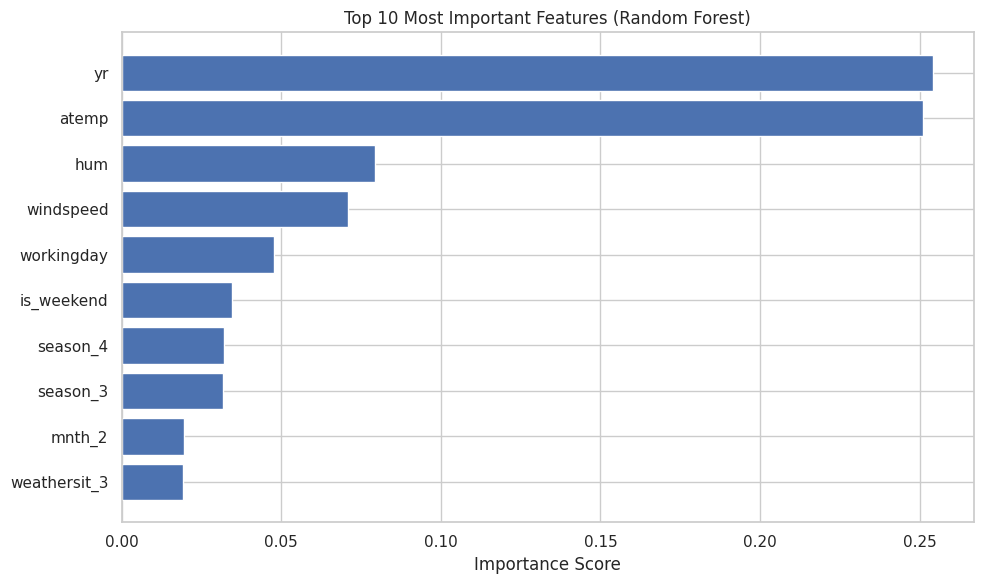

In [58]:
import pandas as pd

best_rf_model.fit(X_train, y_train)

importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# Combine into DataFrame and sort
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Select TOP 10
top10 = feat_imp.head(10)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"])
plt.xlabel("Importance Score")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()

## Random Forest for casual users

### Split the data into training and testing

In [80]:
from sklearn.model_selection import train_test_split
# Features
X = day_df_train.drop(columns=['total_bike_rental', 'registered', 'casual'])
# Variable of interest
y = day_df_train["casual"]
# Split the data 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Train Random Forest regressor for casual users

In [81]:
best_rf_model, best_params, best_cv_r2, grid_obj = run_rf_grid_search(X_train, y_train)
# Fit the model here after finding the best parameters
best_rf_model.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


 Best Parameters Found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


 Best Cross-Validation R²: 0.8014247629838722





RandomForestRegressor(max_features='sqrt', n_estimators=300, random_state=42)

### SHAP values for casual users

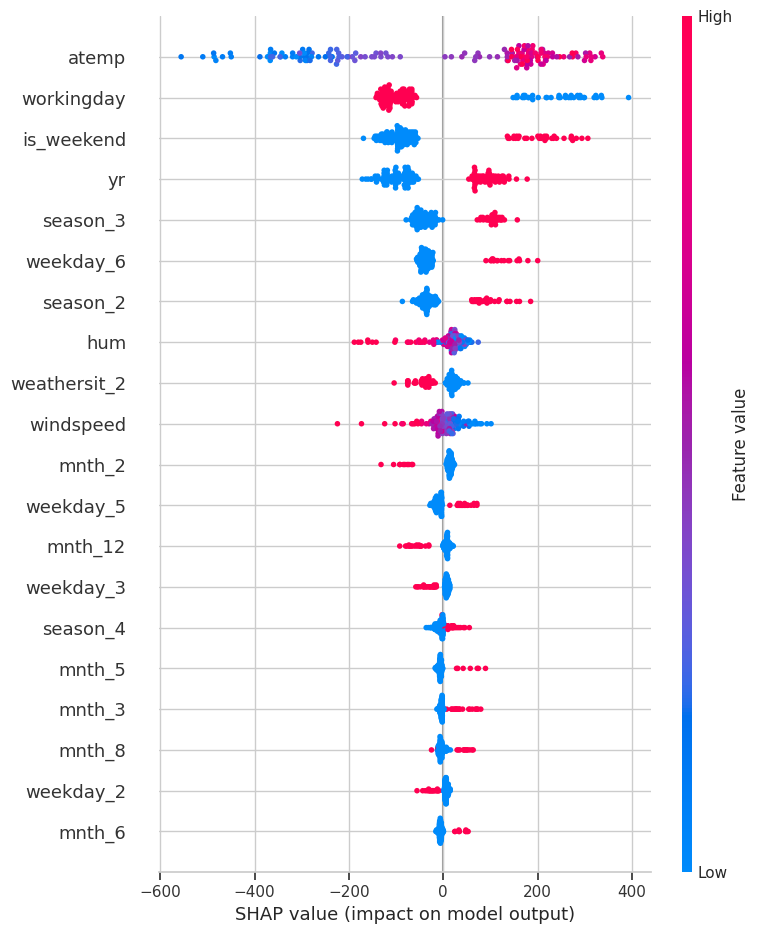

In [61]:
plot_shap_summary(best_rf_model, X_test)

### Feature importances

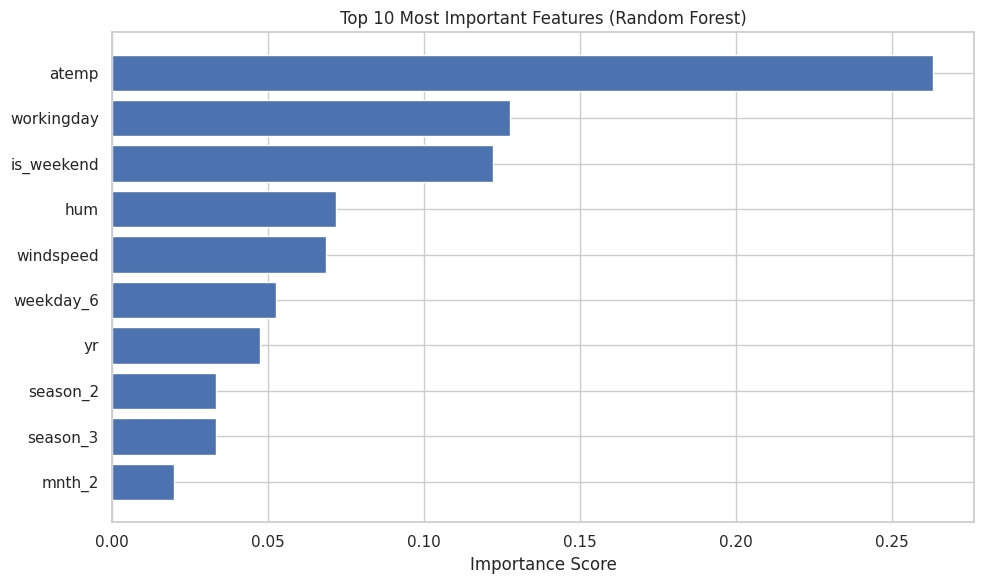

In [62]:
plot_feature_importance(best_rf_model, X_train, y_train)

### Accuracy and residual plots for casual users

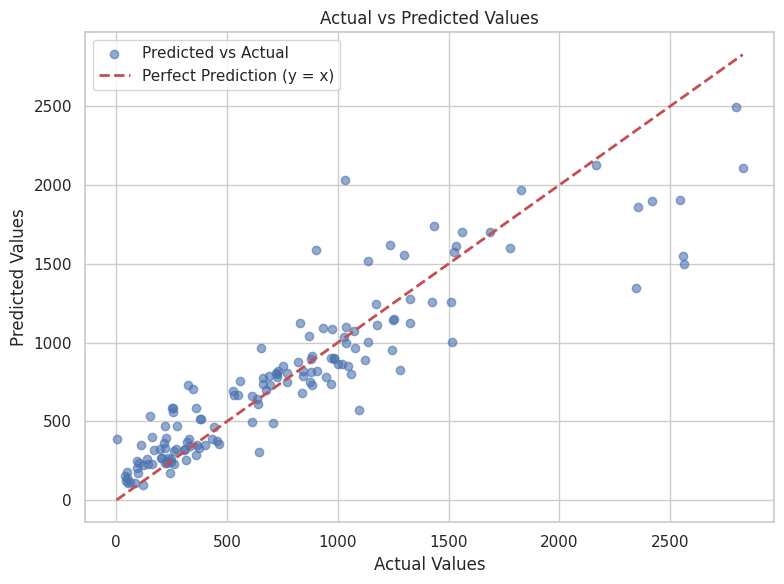

MSE  : 69305.37893101538
RMSE : 263.2591478581806
MAE  : 171.87820105820106


Error Rate: 34.20%


In [82]:
plot_actual_vs_predicted(best_rf_model, X_test, y_test,X_train, y_train)

### LSTM for hourly and daily data

In [64]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ------------------- Load datasets -------------------
df_hourly = pd.read_csv("hour.csv", parse_dates=['dteday'])
df_daily = pd.read_csv("day.csv", parse_dates=['dteday'])

# Ensure necessary columns exist
for col in ['dteday', 'casual', 'registered']:
    if col not in df_hourly.columns:
        raise ValueError(f"{col} not in hourly dataframe")
    if col not in df_daily.columns:
        raise ValueError(f"{col} not in daily dataframe")

# ------------------- Sequence preparation -------------------
def prepare_sequences(df, target_col, sequence_length=24):
    df_numeric = df.select_dtypes(include=[np.number])
    X = df_numeric.drop(columns=[target_col]).values
    y = df_numeric[[target_col]].values

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_scaled = scaler_X.fit_transform(X)
    y_scaled = scaler_y.fit_transform(y)

    X_seq, y_seq = [], []
    for i in range(sequence_length, len(X_scaled)):
        X_seq.append(X_scaled[i-sequence_length:i])
        y_seq.append(y_scaled[i])

    return np.array(X_seq), np.array(y_seq), scaler_X, scaler_y

# ------------------- LSTM model builder -------------------
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, activation='relu', input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# ------------------- Hourly Data Training -------------------
sequence_length_hr = 24

# Casual
X_hr_c, y_hr_c, scalerX_hr_c, scalerY_hr_c = prepare_sequences(df_hourly, 'casual', sequence_length_hr)
split = int(len(X_hr_c)*0.8)
X_train_hr_c, X_test_hr_c = X_hr_c[:split], X_hr_c[split:]
y_train_hr_c, y_test_hr_c = y_hr_c[:split], y_hr_c[split:]

model_hr_c = build_lstm_model(X_train_hr_c.shape[1:])
history_hr_c = model_hr_c.fit(X_train_hr_c, y_train_hr_c, epochs=20, batch_size=32, verbose=1)

# Registered
X_hr_r, y_hr_r, scalerX_hr_r, scalerY_hr_r = prepare_sequences(df_hourly, 'registered', sequence_length_hr)
X_train_hr_r, X_test_hr_r = X_hr_r[:split], X_hr_r[split:]
y_train_hr_r, y_test_hr_r = y_hr_r[:split], y_hr_r[split:]

model_hr_r = build_lstm_model(X_train_hr_r.shape[1:])
history_hr_r = model_hr_r.fit(X_train_hr_r, y_train_hr_r, epochs=20, batch_size=32, verbose=1)

# ------------------- Daily Data Training -------------------
sequence_length_d = 7

# Casual
X_d_c, y_d_c, scalerX_d_c, scalerY_d_c = prepare_sequences(df_daily, 'casual', sequence_length_d)
split = int(len(X_d_c)*0.8)
X_train_d_c, X_test_d_c = X_d_c[:split], X_d_c[split:]
y_train_d_c, y_test_d_c = y_d_c[:split], y_d_c[split:]

model_d_c = build_lstm_model(X_train_d_c.shape[1:])
history_d_c = model_d_c.fit(X_train_d_c, y_train_d_c, epochs=25, batch_size=16, verbose=1)

# Registered
X_d_r, y_d_r, scalerX_d_r, scalerY_d_r = prepare_sequences(df_daily, 'registered', sequence_length_d)
X_train_d_r, X_test_d_r = X_d_r[:split], X_d_r[split:]
y_train_d_r, y_test_d_r = y_d_r[:split], y_d_r[split:]

model_d_r = build_lstm_model(X_train_d_r.shape[1:])
history_d_r = model_d_r.fit(X_train_d_r, y_train_d_r, epochs=25, batch_size=16, verbose=1)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0109
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0034
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0027
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0025
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0021
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0019
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0020
Epoch 8/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0019
Epoch 9/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0017
Epoch 10/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0017
Epoch 11/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0017
Epoch 12/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0016
Epoch 13/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0015
Epoch 14/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0015
Epoch 15/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/st

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


434/434 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0189
Epoch 2/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0087
Epoch 3/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0045
Epoch 4/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0031
Epoch 5/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0026
Epoch 6/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0027
Epoch 7/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0023
Epoch 8/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0023
Epoch 9/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0021
Epoch 10/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0019
Epoch 11/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0018
Epoch 12/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0019
Epoch 13/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0018
Epoch 14/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0016
Epoch 15/20
434/434 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0520
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0235
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0195
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0238
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0199
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0151
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0150
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0155
Epoch 9/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0141
Epoch 10/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0163
Epoch 11/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0148
Epoch 12/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0169
Epoch 13/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0138
Epoch 14/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0118
Epoch 15/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0146
Epoch 16/25
37/37 ━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2143
Epoch 2/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0228
Epoch 3/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0204
Epoch 4/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0146
Epoch 5/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0151
Epoch 6/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0162
Epoch 7/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0129
Epoch 8/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0139
Epoch 9/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0124
Epoch 10/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0112
Epoch 11/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0116
Epoch 12/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0101
Epoch 13/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0126
Epoch 14/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0109
Epoch 15/25
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0106
Epoch 16/25
37/37 ━━━━━━━━━━━

# Model Testing

### Testing LSTM model

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


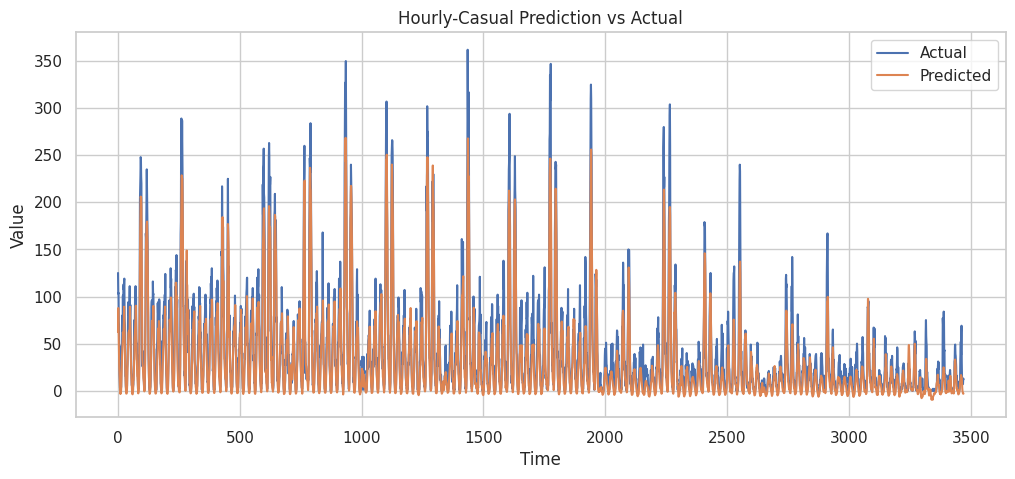

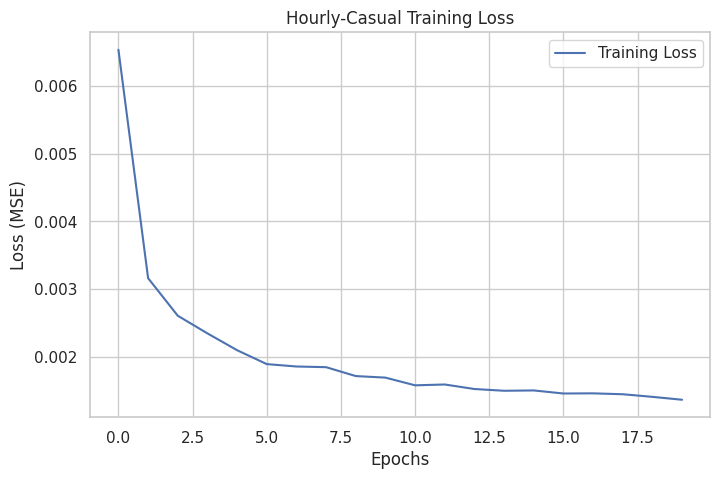

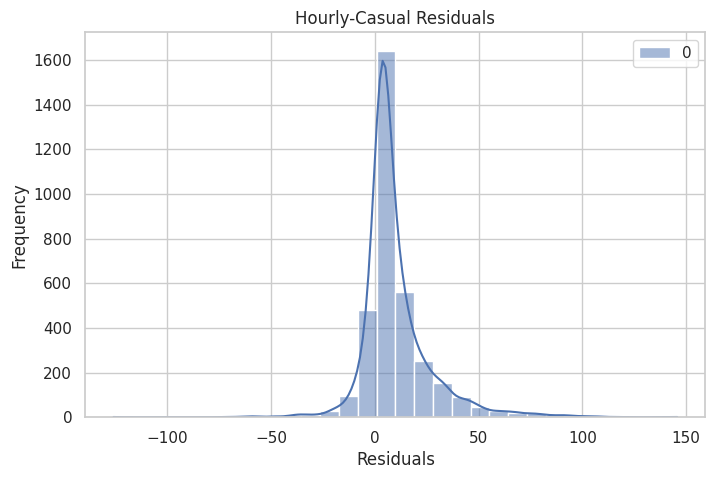

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


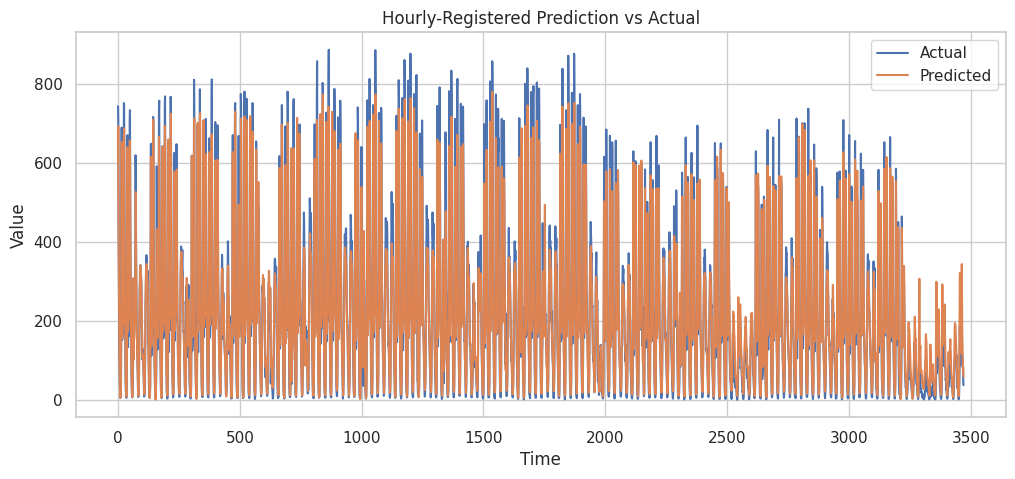

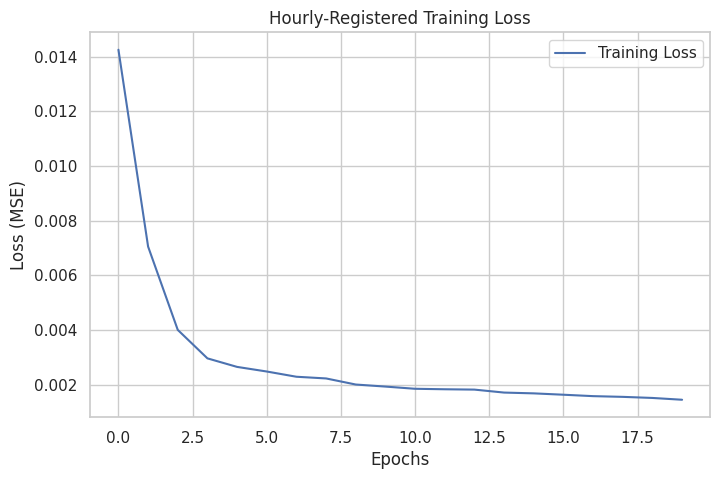

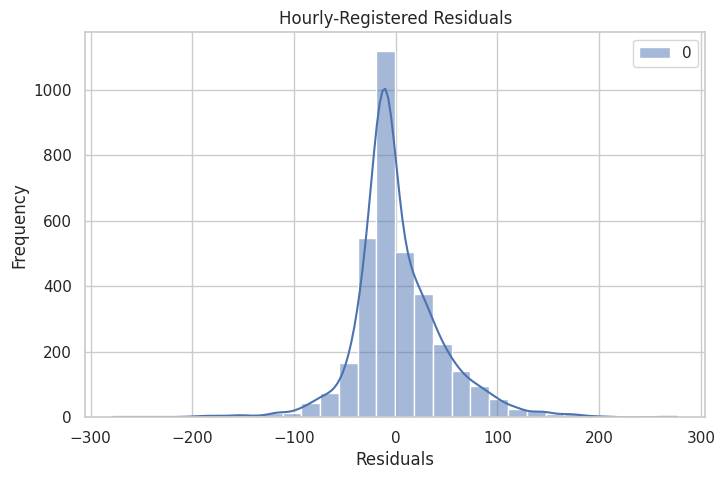

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


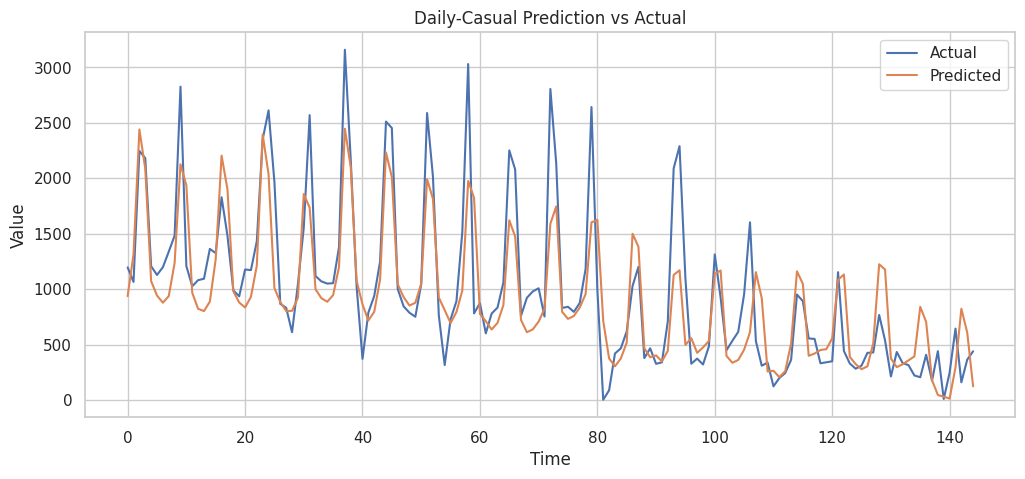

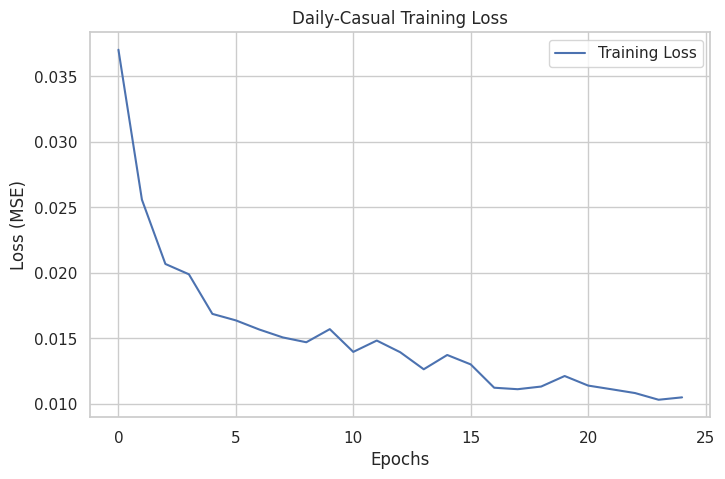

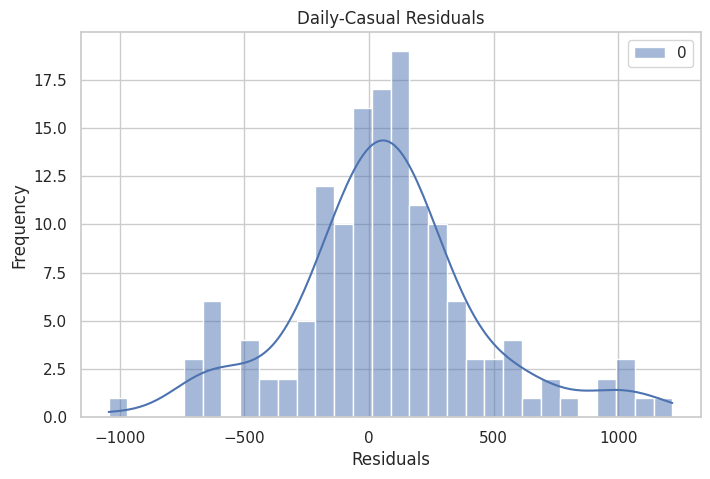

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


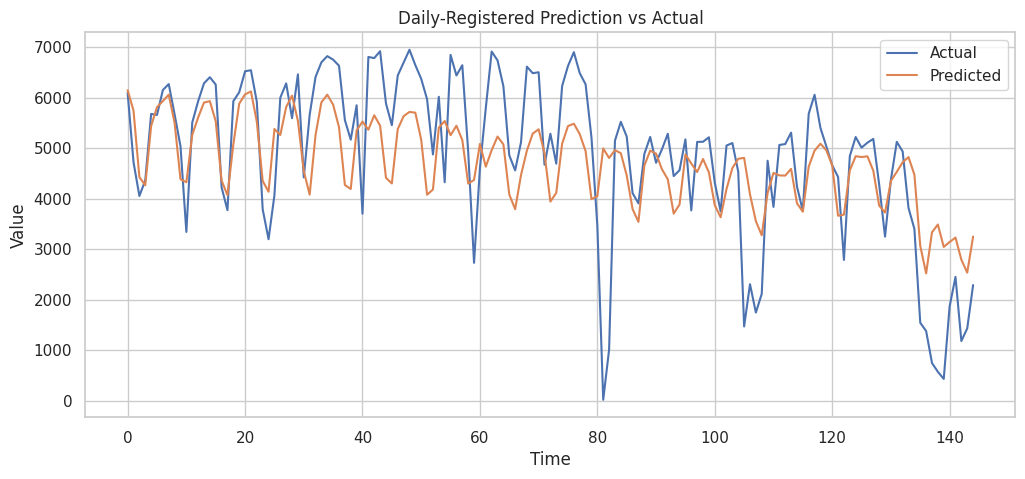

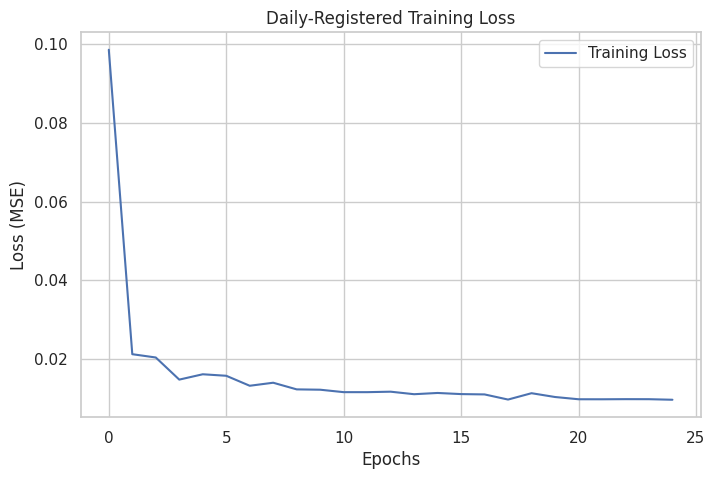

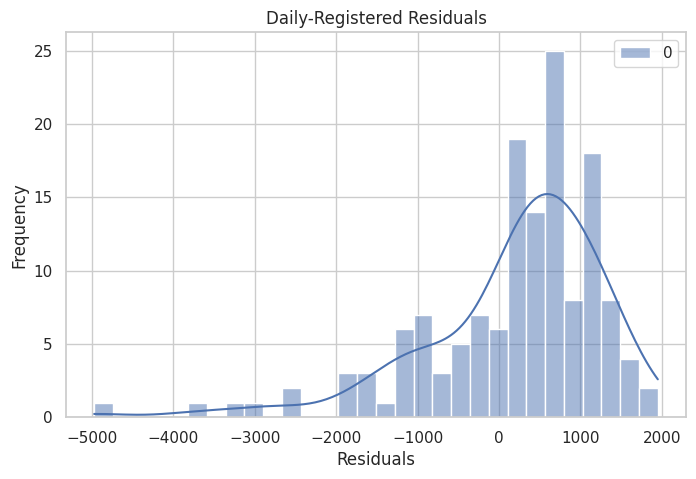

               Model         MAE         RMSE        R²
0      Hourly-Casual   12.495730    19.795785  0.875116
1  Hourly-Registered   30.448324    43.978465  0.945476
2       Daily-Casual  278.895966   389.115270  0.696262
3   Daily-Registered  886.481386  1139.246458  0.479961


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# ------------------- Evaluation function -------------------
def evaluate_model(model, X_test, y_test, scaler_y):
    y_pred = model.predict(X_test)
    y_pred_inv = scaler_y.inverse_transform(y_pred)
    y_test_inv = scaler_y.inverse_transform(y_test)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    r2 = r2_score(y_test_inv, y_pred_inv)

    return mae, rmse, r2, y_test_inv, y_pred_inv

# ------------------- Plot functions -------------------
def plot_predictions(y_true, y_pred, title="Prediction vs Actual"):
    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

def plot_training_history(history, title="Training Loss"):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()

def plot_residuals(y_true, y_pred, title="Residuals Distribution"):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,5))
    sns.histplot(residuals, kde=True, bins=30)
    plt.title(title)
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.show()

# ------------------- Loop through all models -------------------
models_info = [
    ("Hourly-Casual", model_hr_c, X_test_hr_c, y_test_hr_c, scalerY_hr_c, history_hr_c),
    ("Hourly-Registered", model_hr_r, X_test_hr_r, y_test_hr_r, scalerY_hr_r, history_hr_r),
    ("Daily-Casual", model_d_c, X_test_d_c, y_test_d_c, scalerY_d_c, history_d_c),
    ("Daily-Registered", model_d_r, X_test_d_r, y_test_d_r, scalerY_d_r, history_d_r)
]

performance_data = []

for name, model, X_test, y_test, scaler_y, history in models_info:
    mae, rmse, r2, y_test_inv, y_pred_inv = evaluate_model(model, X_test, y_test, scaler_y)
    performance_data.append([name, mae, rmse, r2])

    plot_predictions(y_test_inv, y_pred_inv, f"{name} Prediction vs Actual")
    plot_training_history(history, f"{name} Training Loss")
    plot_residuals(y_test_inv, y_pred_inv, f"{name} Residuals")

# ------------------- Performance Summary Table -------------------
performance_df = pd.DataFrame(performance_data, columns=["Model", "MAE", "RMSE", "R²"])
print(performance_df)


109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


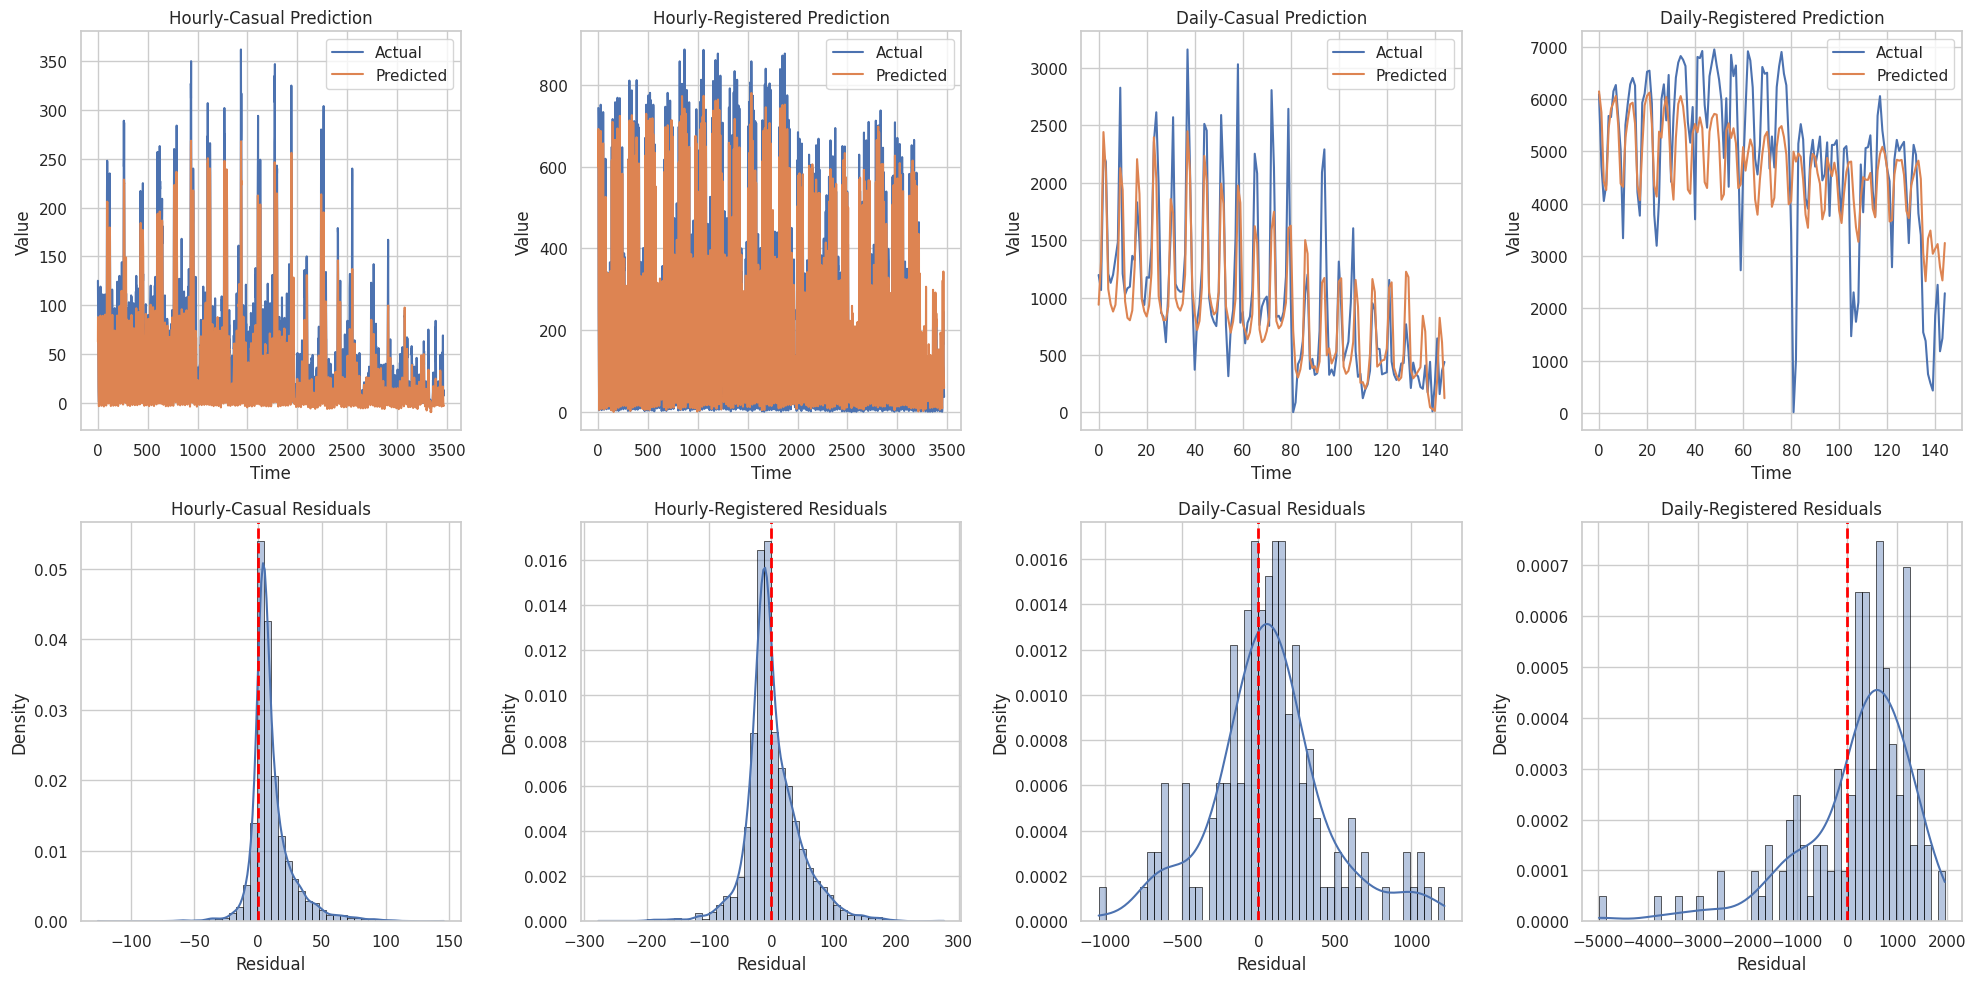

In [66]:
# ------------------------------
# Inverse scaling for all models
# ------------------------------

y_test_hr_c_inv = scalerY_hr_c.inverse_transform(y_test_hr_c)
y_pred_hr_c_inv = scalerY_hr_c.inverse_transform(model_hr_c.predict(X_test_hr_c))

y_test_hr_r_inv = scalerY_hr_r.inverse_transform(y_test_hr_r)
y_pred_hr_r_inv = scalerY_hr_r.inverse_transform(model_hr_r.predict(X_test_hr_r))

y_test_d_c_inv = scalerY_d_c.inverse_transform(y_test_d_c)
y_pred_d_c_inv = scalerY_d_c.inverse_transform(model_d_c.predict(X_test_d_c))

y_test_d_r_inv = scalerY_d_r.inverse_transform(y_test_d_r)
y_pred_d_r_inv = scalerY_d_r.inverse_transform(model_d_r.predict(X_test_d_r))

import matplotlib.pyplot as plt
import seaborn as sns

# Model info
models_info = {
    "Hourly-Casual": (y_test_hr_c_inv, y_pred_hr_c_inv),
    "Hourly-Registered": (y_test_hr_r_inv, y_pred_hr_r_inv),
    "Daily-Casual": (y_test_d_c_inv, y_pred_d_c_inv),
    "Daily-Registered": (y_test_d_r_inv, y_pred_d_r_inv)
}

plt.figure(figsize=(20, 10))

# ------------------- Top Row: Predictions vs Actual -------------------
for i, (name, (y_true, y_pred)) in enumerate(models_info.items(), 1):
    plt.subplot(2, 4, i)
    plt.plot(y_true, label="Actual")
    plt.plot(y_pred, label="Predicted")
    plt.title(f"{name} Prediction")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()

# ------------------- Bottom Row: Residuals (Histogram + KDE) -------------------
bins = 50
for i, (name, (y_true, y_pred)) in enumerate(models_info.items(), 1):
    residuals = y_true - y_pred
    plt.subplot(2, 4, i+4)
    sns.histplot(residuals.flatten(), bins=bins, kde=True, stat="density",
                 alpha=0.4, edgecolor='black')
    plt.axvline(0, color='red', linestyle='--', linewidth=2)
    plt.title(f"{name} Residuals")
    plt.xlabel("Residual")
    plt.ylabel("Density")

plt.tight_layout()
plt.show()


###LSTM Confusion Matrix


Confusion Matrix for Hourly-Casual (3-Class Low/Med/High):
[[1145   47    0]
 [ 294  779   36]
 [   3  227  940]]



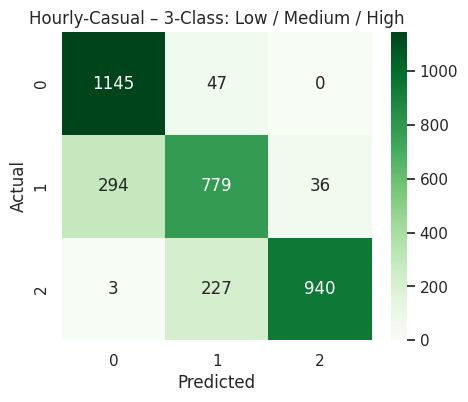


Hourly-Registered – Binary High/Low:
[[1962   89]
 [ 165 1255]]

Hourly-Registered – 3-Class Low/Med/High:
[[1015  130    2]
 [  27 1056   62]
 [   0  141 1038]]

Hourly-Registered – Increase/Decrease:
[[1644  320]
 [ 266 1240]]

Hourly-Registered – Custom Categories:
[[1087  130    1    0]
 [  27 1275   68    0]
 [   0   91  598    8]
 [   0    0   47  139]]



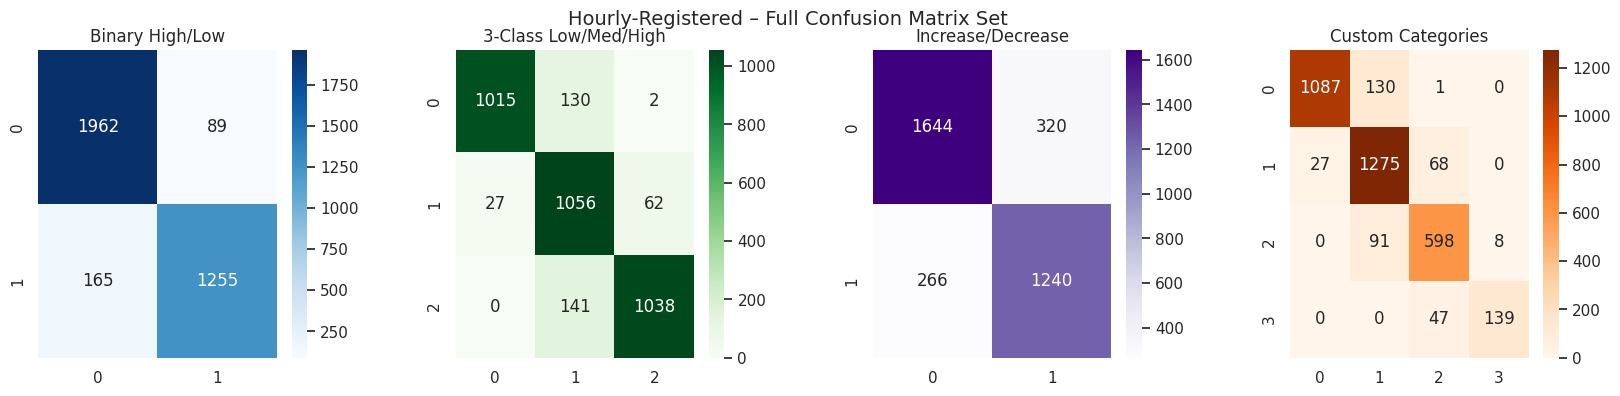


Confusion Matrix for Daily-Casual (3-Class Low/Med/High):
[[35 10  3]
 [ 6 34  8]
 [ 1 15 33]]



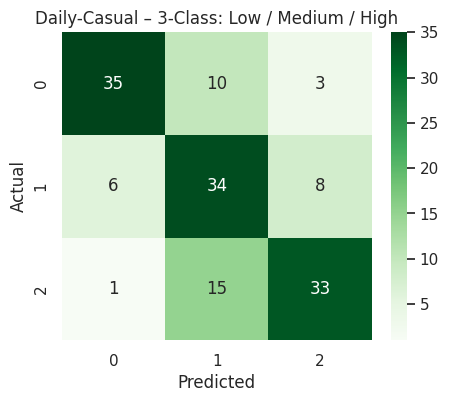


Daily-Registered – Binary High/Low:
[[50  8]
 [32 55]]

Daily-Registered – 3-Class Low/Med/High:
[[39  9  0]
 [24 21  3]
 [ 2 33 14]]

Daily-Registered – Increase/Decrease:
[[51 22]
 [22 49]]

Daily-Registered – Custom Categories:
[[140   0   0]
 [  2   0   0]
 [  3   0   0]]



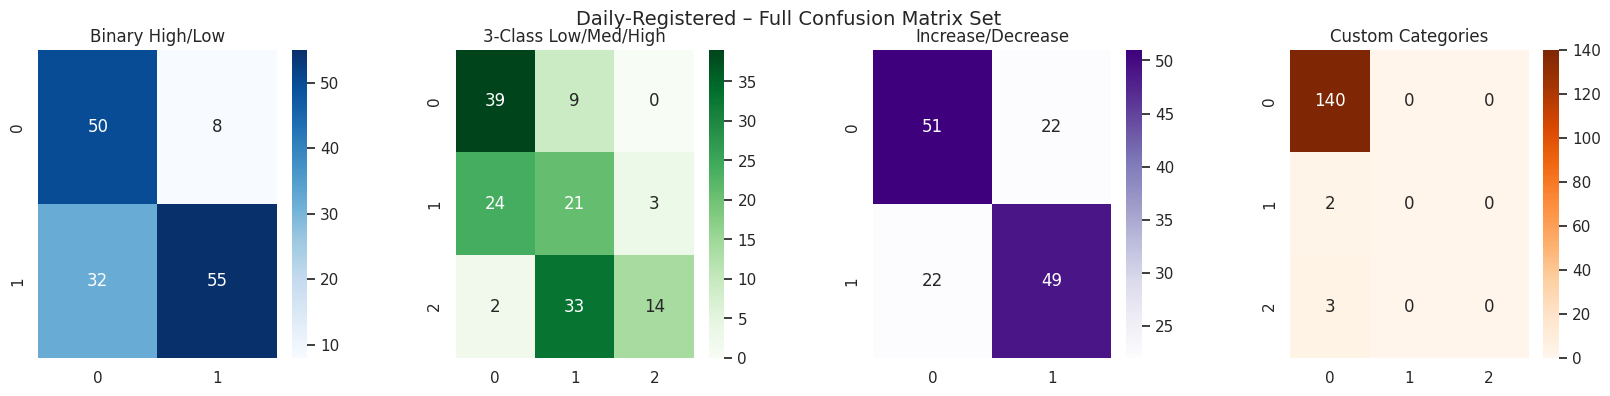

In [67]:
# =====================================================================
# CONFUSION MATRIX FUNCTIONS
# =====================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# ---------- A) 3-Class Confusion Matrix (Casual Models) ----------
def plot_confusion_matrix_3class(y_true, y_pred, model_name):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # Create 3 equal quantile bins
    bins = np.quantile(y_true, [0, 0.33, 0.66, 1]) + np.array([0, 1e-6, 1e-6, 0])

    y_true_3 = pd.cut(y_true, bins, labels=[0, 1, 2], include_lowest=True)
    y_pred_3 = pd.cut(y_pred, bins, labels=[0, 1, 2], include_lowest=True)

    # Convert to integer codes & fix -1
    y_true_3 = np.where(y_true_3.codes == -1, 0, y_true_3.codes)
    y_pred_3 = np.where(y_pred_3.codes == -1, 0, y_pred_3.codes)

    cm = confusion_matrix(y_true_3, y_pred_3)
    print(f"\nConfusion Matrix for {model_name} (3-Class Low/Med/High):\n{cm}\n")

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"{model_name} – 3-Class: Low / Medium / High")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



# ---------- B) Full Confusion Matrix Set (Registered Models) ----------
def plot_confusion_matrices_full(y_true, y_pred, model_name):

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    plt.subplots_adjust(wspace=0.4)

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # =========================================================
    # 1) Binary High/Low
    # =========================================================
    threshold = y_true.mean()
    y_true_bin = (y_true > threshold).astype(int)
    y_pred_bin = (y_pred > threshold).astype(int)

    cm_bin = confusion_matrix(y_true_bin, y_pred_bin)
    print(f"\n{model_name} – Binary High/Low:\n{cm_bin}\n")

    sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title("Binary High/Low")


    # =========================================================
    # 2) 3-Class Low/Med/High
    # =========================================================
    bins = np.quantile(y_true, [0, 0.33, 0.66, 1]) + np.array([0, 1e-6, 1e-6, 0])
    y_true_3 = pd.cut(y_true, bins, labels=[0, 1, 2], include_lowest=True)
    y_pred_3 = pd.cut(y_pred, bins, labels=[0, 1, 2], include_lowest=True)

    y_true_3 = np.where(y_true_3.codes == -1, 0, y_true_3.codes)
    y_pred_3 = np.where(y_pred_3.codes == -1, 0, y_pred_3.codes)

    cm_3 = confusion_matrix(y_true_3, y_pred_3)
    print(f"{model_name} – 3-Class Low/Med/High:\n{cm_3}\n")

    sns.heatmap(cm_3, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title("3-Class Low/Med/High")


    # =========================================================
    # 3) Increase/Decrease
    # =========================================================
    y_true_diff = (np.diff(y_true) > 0).astype(int)
    y_pred_diff = (np.diff(y_pred) > 0).astype(int)

    cm_diff = confusion_matrix(y_true_diff, y_pred_diff)
    print(f"{model_name} – Increase/Decrease:\n{cm_diff}\n")

    sns.heatmap(cm_diff, annot=True, fmt='d', cmap='Purples', ax=axes[2])
    axes[2].set_title("Increase/Decrease")


    # =========================================================
    # 4) Custom bins
    # =========================================================
    custom_bins = [0, 100, 300, 600, 1200]
    y_true_custom = pd.cut(y_true, custom_bins, labels=[0, 1, 2, 3], include_lowest=True)
    y_pred_custom = pd.cut(y_pred, custom_bins, labels=[0, 1, 2, 3], include_lowest=True)

    y_true_custom = np.where(y_true_custom.codes == -1, 0, y_true_custom.codes)
    y_pred_custom = np.where(y_pred_custom.codes == -1, 0, y_pred_custom.codes)

    cm_custom = confusion_matrix(y_true_custom, y_pred_custom)
    print(f"{model_name} – Custom Categories:\n{cm_custom}\n")

    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', ax=axes[3])
    axes[3].set_title("Custom Categories")

    plt.suptitle(f"{model_name} – Full Confusion Matrix Set", fontsize=14)
    plt.show()



# =====================================================================
# DEFINE YOUR VARIABLES (THE FIXED BLOCK)
# =====================================================================

model_names = [
    "Hourly-Casual",
    "Hourly-Registered",
    "Daily-Casual",
    "Daily-Registered"
]

y_test_list = [
    y_test_hr_c_inv,   # Hourly Casual
    y_test_hr_r_inv,   # Hourly Registered
    y_test_d_c_inv,    # Daily Casual
    y_test_d_r_inv     # Daily Registered
]

y_pred_list = [
    y_pred_hr_c_inv,   # Hourly Casual
    y_pred_hr_r_inv,   # Hourly Registered
    y_pred_d_c_inv,    # Daily Casual
    y_pred_d_r_inv     # Daily Registered
]


# =====================================================================
# RUN CONFUSION MATRICES
# =====================================================================
for name, y_true, y_pred in zip(model_names, y_test_list, y_pred_list):

    if "Casual" in name:
        plot_confusion_matrix_3class(y_true, y_pred, name)

    else:
        plot_confusion_matrices_full(y_true, y_pred, name)
